# Machine Learning Model Development

## Palm Oil Waste Prediction Using Stacking Ensemble Learning

This notebook develops and evaluates machine learning models for predicting four palm oil waste streams:

- Empty Fruit Bunch (EFB)
- Palm Kernel Shell (PKS)
- Palm Oil Mill Effluent (POME)
- Mesocarp Fibre (MF)

The modelling framework compares:

- Random Forest
- XGBoost
- Long Short-Term Memory (LSTM)
- Elastic Net stacking ensemble

Model development uses rolling-origin time-series validation, while observations from 2022–2024 are retained as an independent test set.

Model performance is evaluated using RMSE, MAE, MAPE and R². Results are also compared with a simple FFB conversion-factor baseline and sensitivity analysis excluding FFB.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

## 1. Modelling Setup and Reproducibility

A fixed random seed is used to improve reproducibility across model runs. The dataset is then loaded and divided chronologically into model-development and independent test periods.

In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Random seed:", RANDOM_SEED)

Random seed: 42


In [3]:
df = pd.read_csv("../data/palm_oil_waste_dataset_1964_2024.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (732, 14)


,Year,Month,Month_Number,Quarter,FFB_1000MT,EFB_1000MT,PKS_1000MT,POME_1000MT,Mesocarp_Fibre_1000MT,Avg_Temperature_C,Rainfall_mm,Humidity_pct,Wind_Speed_ms,Solar_Radiation_Wm2
0,1964,Jan,1,Q1,26.85,5.907,1.611,17.453,3.491,27.27,45.84,82.20,2.00,187.66
1,1964,Feb,2,Q1,32.22,7.088,1.933,20.943,4.189,28.28,67.60,81.26,2.11,192.43
2,1964,Mar,3,Q1,53.70,11.814,3.222,34.905,6.981,28.26,154.10,84.20,2.20,181.76
3,1964,Apr,4,Q2,69.81,15.358,4.189,45.377,9.075,28.22,221.79,87.13,2.09,167.18
4,1964,May,5,Q2,75.18,16.540,4.511,48.867,9.773,27.24,308.64,88.19,2.00,157.86


In [4]:
quarter_mapping = {
    "Q1": 1,
    "Q2": 2,
    "Q3": 3,
    "Q4": 4
}

df["Quarter"] = df["Quarter"].map(quarter_mapping)

In [5]:
features = [
    "Year",
    "Month_Number",
    "Quarter",
    "FFB_1000MT",
    "Avg_Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Wind_Speed_ms",
    "Solar_Radiation_Wm2"
]

targets = [
    "EFB_1000MT",
    "PKS_1000MT",
    "POME_1000MT",
    "Mesocarp_Fibre_1000MT"
]

X = df[features].copy()
y = df[targets].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (732, 9)
y shape: (732, 4)


In [6]:
train_mask = df["Year"] <= 2021
test_mask = df["Year"] >= 2022

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Development period:", X_train.shape, y_train.shape)
print("Independent test:", X_test.shape, y_test.shape)

Development period: (696, 9) (696, 4)
Independent test: (36, 9) (36, 4)


In [7]:
validation_years = range(2012, 2022)

rolling_splits = []

for val_year in validation_years:

    train_indices = df.index[
        (df["Year"] >= 1964) &
        (df["Year"] < val_year)
    ].to_numpy()

    val_indices = df.index[
        df["Year"] == val_year
    ].to_numpy()

    rolling_splits.append((train_indices, val_indices))

print("Rolling-origin splits:", len(rolling_splits))

Rolling-origin splits: 10


## 2. Model Evaluation Metrics

Four complementary metrics are used to evaluate predictive performance:

- **RMSE** measures the typical magnitude of prediction errors while placing greater weight on large errors.
- **MAE** measures the average absolute prediction error.
- **MAPE** expresses the average absolute error as a percentage of the observed values.
- **R²** measures the proportion of variation in the target explained by the model.

Lower RMSE, MAE and MAPE values indicate smaller prediction errors, while an R² value closer to 1 indicates a stronger fit.

In [8]:
def calculate_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R2": r2_score(y_true, y_pred)
    }

## 3. Random Forest Model

Random Forest is an ensemble learning method that combines predictions from multiple decision trees. Each tree is trained using variations of the training data and predictor selection, and the final regression prediction is obtained by averaging predictions across the trees.

Random Forest is suitable for modelling nonlinear relationships and interactions between predictors and does not require feature scaling.

The model is first demonstrated for EFB using the first rolling-origin validation split before being extended across all validation folds and target variables.

In [9]:
# First rolling-origin split
train_idx, val_idx = rolling_splits[0]

X_rf_train = X.loc[train_idx]
X_rf_val = X.loc[val_idx]

y_rf_train = y.loc[train_idx, "EFB_1000MT"]
y_rf_val = y.loc[val_idx, "EFB_1000MT"]

print("Training period:",
      df.loc[train_idx, "Year"].min(),
      "to",
      df.loc[train_idx, "Year"].max())

print("Validation year:",
      df.loc[val_idx, "Year"].unique()[0])

print("Training observations:", len(X_rf_train))
print("Validation observations:", len(X_rf_val))

Training period: 1964 to 2011
Validation year: 2012
Training observations: 576
Validation observations: 12


In [10]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_model.fit(X_rf_train, y_rf_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [11]:
rf_val_pred = rf_model.predict(X_rf_val)

comparison = pd.DataFrame({
    "Actual_EFB": y_rf_val.values,
    "Predicted_EFB": rf_val_pred
})

comparison

,Actual_EFB,Predicted_EFB
0,10.340,10.301940
1,12.408,12.386130
2,20.680,20.760115
3,26.884,26.758095
4,28.952,29.338575
5,24.816,25.251340
6,20.680,20.741600
7,18.612,18.667300
8,14.476,14.499100
9,12.408,12.380865


In [12]:
rf_metrics = calculate_metrics(
    y_rf_val,
    rf_val_pred
)

for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

RMSE: 0.1767
MAE: 0.1115
MAPE: 0.5391
R2: 0.9993


### 3.1 Rolling-Origin Validation for Random Forest

Random Forest performance is evaluated across all ten rolling-origin validation folds. For each fold, the model is trained using only observations preceding the validation year and evaluated on the subsequent 12-month period.

This provides a more robust assessment of temporal model performance than evaluation on a single validation year.

In [13]:
rf_fold_results = []

for split_number, (train_idx, val_idx) in enumerate(
    rolling_splits,
    start=1
):
    
    X_fold_train = X.loc[train_idx]
    X_fold_val = X.loc[val_idx]
    
    y_fold_train = y.loc[train_idx, "EFB_1000MT"]
    y_fold_val = y.loc[val_idx, "EFB_1000MT"]
    
    rf_model = RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    
    rf_model.fit(X_fold_train, y_fold_train)
    
    predictions = rf_model.predict(X_fold_val)
    
    metrics = calculate_metrics(
        y_fold_val,
        predictions
    )
    
    rf_fold_results.append({
        "Split": split_number,
        "Validation_Year": df.loc[val_idx, "Year"].iloc[0],
        **metrics
    })

rf_fold_results = pd.DataFrame(rf_fold_results)

rf_fold_results.round(4)

,Split,Validation_Year,RMSE,MAE,MAPE,R2
0,1,2012,0.1767,0.1115,0.5391,0.9993
1,2,2013,0.1551,0.0898,0.4667,0.9994
2,3,2014,0.0715,0.0405,0.1739,0.9999
3,4,2015,0.1526,0.1018,0.5030,0.9995
4,5,2016,0.3680,0.1679,0.6250,0.9975
5,6,2017,0.5719,0.2186,0.7600,0.9943
6,7,2018,1.4229,0.5984,1.9090,0.9708
7,8,2019,0.6332,0.2593,0.8215,0.9943
8,9,2020,1.9584,0.8321,2.2487,0.9566
9,10,2021,2.3996,1.0207,2.5440,0.9459


In [14]:
print("Random Forest EFB Rolling-Origin Performance")
print("-" * 45)

print(f"Mean RMSE: {rf_fold_results['RMSE'].mean():.4f}")
print(f"Mean MAE:  {rf_fold_results['MAE'].mean():.4f}")
print(f"Mean MAPE: {rf_fold_results['MAPE'].mean():.4f}%")
print(f"Mean R²:   {rf_fold_results['R2'].mean():.4f}")

print(f"\nRMSE standard deviation: {rf_fold_results['RMSE'].std():.4f}")

Random Forest EFB Rolling-Origin Performance
---------------------------------------------
Mean RMSE: 0.7910
Mean MAE:  0.3441
Mean MAPE: 1.0591%
Mean R²:   0.9858

RMSE standard deviation: 0.8372


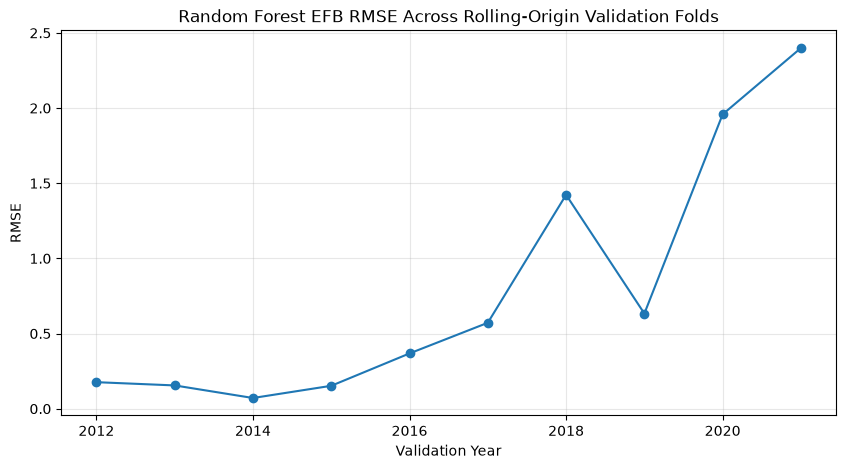

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    rf_fold_results["Validation_Year"],
    rf_fold_results["RMSE"],
    marker="o"
)

plt.xlabel("Validation Year")
plt.ylabel("RMSE")
plt.title("Random Forest EFB RMSE Across Rolling-Origin Validation Folds")
plt.grid(alpha=0.3)

plt.show()

In [16]:
rf_fold_results[
    ["Validation_Year", "RMSE", "MAE", "MAPE", "R2"]
].sort_values("RMSE", ascending=False).round(4)

,Validation_Year,RMSE,MAE,MAPE,R2
9,2021,2.3996,1.0207,2.5440,0.9459
8,2020,1.9584,0.8321,2.2487,0.9566
6,2018,1.4229,0.5984,1.9090,0.9708
7,2019,0.6332,0.2593,0.8215,0.9943
5,2017,0.5719,0.2186,0.7600,0.9943
4,2016,0.3680,0.1679,0.6250,0.9975
0,2012,0.1767,0.1115,0.5391,0.9993
1,2013,0.1551,0.0898,0.4667,0.9994
3,2015,0.1526,0.1018,0.5030,0.9995
2,2014,0.0715,0.0405,0.1739,0.9999


In [17]:
worst_fold = rf_fold_results.loc[
    rf_fold_results["RMSE"].idxmax()
]

best_fold = rf_fold_results.loc[
    rf_fold_results["RMSE"].idxmin()
]

print(
    f"Lowest RMSE: {int(best_fold['Validation_Year'])} "
    f"({best_fold['RMSE']:.4f})"
)

print(
    f"Highest RMSE: {int(worst_fold['Validation_Year'])} "
    f"({worst_fold['RMSE']:.4f})"
)

Lowest RMSE: 2014 (0.0715)
Highest RMSE: 2021 (2.3996)


### 3.2 Multi-Target Random Forest Validation

The rolling-origin validation procedure is extended to all four palm oil waste targets. A separate Random Forest model is fitted for each target within each validation fold.

This enables comparison of predictive performance across EFB, PKS, POME and Mesocarp Fibre while preserving the chronological validation structure.

In [18]:
rf_all_results = []

for target in targets:
    
    for split_number, (train_idx, val_idx) in enumerate(
        rolling_splits,
        start=1
    ):
        
        X_fold_train = X.loc[train_idx]
        X_fold_val = X.loc[val_idx]
        
        y_fold_train = y.loc[train_idx, target]
        y_fold_val = y.loc[val_idx, target]
        
        model = RandomForestRegressor(
            n_estimators=200,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        
        model.fit(X_fold_train, y_fold_train)
        
        predictions = model.predict(X_fold_val)
        
        metrics = calculate_metrics(
            y_fold_val,
            predictions
        )
        
        rf_all_results.append({
            "Target": target,
            "Split": split_number,
            "Validation_Year": df.loc[val_idx, "Year"].iloc[0],
            **metrics
        })

rf_all_results = pd.DataFrame(rf_all_results)

print("Number of validation results:",
      len(rf_all_results))

rf_all_results.head()

Number of validation results: 40


,Target,Split,Validation_Year,RMSE,MAE,MAPE,R2
0,EFB_1000MT,1,2012,0.176718,0.111523,0.539123,0.999349
1,EFB_1000MT,2,2013,0.155094,0.089828,0.466688,0.999428
2,EFB_1000MT,3,2014,0.071471,0.040460,0.173908,0.999894
3,EFB_1000MT,4,2015,0.152625,0.101779,0.503017,0.999530
4,EFB_1000MT,5,2016,0.367957,0.167877,0.625012,0.997457


In [19]:
rf_summary = (
    rf_all_results
    .groupby("Target")[["RMSE", "MAE", "MAPE", "R2"]]
    .agg(["mean", "std"])
    .round(4)
)

rf_summary

RMSE             MAE            MAPE              R2  \
                         mean     std    mean     std    mean     std    mean   
Target                                                                          
EFB_1000MT             0.7910  0.8372  0.3441  0.3471  1.0591  0.8427  0.9858   
Mesocarp_Fibre_1000MT  0.4648  0.4864  0.2037  0.2057  1.0651  0.8494  0.9860   
PKS_1000MT             0.2106  0.2159  0.0917  0.0898  1.0368  0.7965  0.9867   
POME_1000MT            2.2913  2.3980  0.9986  1.0108  1.0422  0.8361  0.9864   

                               
                          std  
Target                         
EFB_1000MT             0.0203  
Mesocarp_Fibre_1000MT  0.0196  
PKS_1000MT             0.0183  
POME_1000MT            0.0192

### 3.3 Time-Series-Aware Hyperparameter Tuning

The initial Random Forest model used a fixed configuration for demonstration purposes. Model hyperparameters are now selected systematically using the rolling-origin validation framework.

Candidate configurations are evaluated only within the model-development period. The independent 2022–2024 test set is not used for hyperparameter selection.

RMSE is used as the primary model-selection metric.

In [20]:
rf_parameter_grid = [
    {
        "n_estimators": 100,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": 1.0
    },
    {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": 1.0
    },
    {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": 1.0
    },
    {
        "n_estimators": 200,
        "max_depth": 10,
        "min_samples_leaf": 1,
        "max_features": 1.0
    },
    {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": 1.0
    },
    {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    }
]

print("Candidate configurations:", len(rf_parameter_grid))

Candidate configurations: 6


In [21]:
rf_tuning_results = []

target = "EFB_1000MT"

for config_number, params in enumerate(
    rf_parameter_grid,
    start=1
):
    
    fold_rmse = []
    
    for train_idx, val_idx in rolling_splits:
        
        model = RandomForestRegressor(
            **params,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        
        model.fit(
            X.loc[train_idx],
            y.loc[train_idx, target]
        )
        
        predictions = model.predict(
            X.loc[val_idx]
        )
        
        rmse = np.sqrt(
            mean_squared_error(
                y.loc[val_idx, target],
                predictions
            )
        )
        
        fold_rmse.append(rmse)
    
    rf_tuning_results.append({
        "Configuration": config_number,
        **params,
        "Mean_RMSE": np.mean(fold_rmse),
        "SD_RMSE": np.std(fold_rmse, ddof=1)
    })

rf_tuning_results = pd.DataFrame(rf_tuning_results)

rf_tuning_results.sort_values(
    "Mean_RMSE"
).round(4)

C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\utils\par

,Configuration,n_estimators,max_depth,min_samples_leaf,max_features,Mean_RMSE,SD_RMSE
3,4,200,10.0,1,1.0,0.7770,0.8098
2,3,300,NaN,1,1.0,0.7817,0.8204
1,2,200,NaN,1,1.0,0.7910,0.8372
0,1,100,NaN,1,1.0,0.7927,0.8192
4,5,200,NaN,2,1.0,0.8088,0.8438
5,6,200,NaN,1,sqrt,1.4720,1.2031


In [22]:
best_rf_row = rf_tuning_results.loc[
    rf_tuning_results["Mean_RMSE"].idxmin()
]

best_rf_params = {
    "n_estimators": int(best_rf_row["n_estimators"]),
    "max_depth": (
        None
        if pd.isna(best_rf_row["max_depth"])
        else int(best_rf_row["max_depth"])
    ),
    "min_samples_leaf": int(best_rf_row["min_samples_leaf"]),
    "max_features": best_rf_row["max_features"]
}

print("Best Random Forest parameters:")
print(best_rf_params)

print(
    f"\nMean validation RMSE: "
    f"{best_rf_row['Mean_RMSE']:.4f}"
)

Best Random Forest parameters:
{'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 1.0}

Mean validation RMSE: 0.7770


### 3.4 Target-Specific Random Forest Hyperparameters

Because the four waste streams are modelled separately, hyperparameter selection is performed independently for each target. Each candidate configuration is evaluated using mean RMSE across the ten rolling-origin validation folds.

In [23]:
rf_target_tuning = []

for target in targets:
    
    for config_number, params in enumerate(
        rf_parameter_grid,
        start=1
    ):
        
        fold_rmse = []
        
        for train_idx, val_idx in rolling_splits:
            
            model = RandomForestRegressor(
                **params,
                random_state=RANDOM_SEED,
                n_jobs=-1
            )
            
            model.fit(
                X.loc[train_idx],
                y.loc[train_idx, target]
            )
            
            predictions = model.predict(
                X.loc[val_idx]
            )
            
            rmse = np.sqrt(
                mean_squared_error(
                    y.loc[val_idx, target],
                    predictions
                )
            )
            
            fold_rmse.append(rmse)
        
        rf_target_tuning.append({
            "Target": target,
            "Configuration": config_number,
            **params,
            "Mean_RMSE": np.mean(fold_rmse),
            "SD_RMSE": np.std(fold_rmse, ddof=1)
        })

rf_target_tuning = pd.DataFrame(rf_target_tuning)

C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\utils\par

In [24]:
best_rf_by_target = (
    rf_target_tuning
    .loc[
        rf_target_tuning
        .groupby("Target")["Mean_RMSE"]
        .idxmin()
    ]
    .sort_values("Target")
    .reset_index(drop=True)
)

best_rf_by_target[
    [
        "Target",
        "Configuration",
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "max_features",
        "Mean_RMSE",
        "SD_RMSE"
    ]
].round(4)

,Target,Configuration,n_estimators,max_depth,min_samples_leaf,max_features,Mean_RMSE,SD_RMSE
0,EFB_1000MT,4,200,10.0,1,1.0,0.7770,0.8098
1,Mesocarp_Fibre_1000MT,4,200,10.0,1,1.0,0.4577,0.4730
2,PKS_1000MT,3,300,NaN,1,1.0,0.2098,0.2122
3,POME_1000MT,3,300,NaN,1,1.0,2.2511,2.3040


### 3.5 Final Random Forest Evaluation

After hyperparameter selection using rolling-origin validation, a final Random Forest model is fitted for each waste target using the complete 1964–2021 development dataset.

The fitted models are then evaluated on the independent 2022–2024 test period, which was not used for model training or hyperparameter selection.

In [25]:
rf_test_results = []
rf_test_predictions = {}
rf_final_models = {}

for _, row in best_rf_by_target.iterrows():
    
    target = row["Target"]
    
    max_depth = (
        None
        if pd.isna(row["max_depth"])
        else int(row["max_depth"])
    )
    
    model = RandomForestRegressor(
        n_estimators=int(row["n_estimators"]),
        max_depth=max_depth,
        min_samples_leaf=int(row["min_samples_leaf"]),
        max_features=row["max_features"],
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    
    # Train using the complete development period
    model.fit(
        X_train,
        y_train[target]
    )
    
    # Predict the untouched independent test period
    predictions = model.predict(X_test)
    
    metrics = calculate_metrics(
        y_test[target],
        predictions
    )
    
    rf_final_models[target] = model
    rf_test_predictions[target] = predictions
    
    rf_test_results.append({
        "Target": target,
        **metrics
    })

rf_test_results = pd.DataFrame(rf_test_results)

rf_test_results.round(4)

,Target,RMSE,MAE,MAPE,R2
0,EFB_1000MT,1.4167,0.6304,1.5771,0.9829
1,Mesocarp_Fibre_1000MT,0.8592,0.3801,1.6077,0.9820
2,PKS_1000MT,0.4069,0.1774,1.6141,0.9811
3,POME_1000MT,4.4452,1.9257,1.6124,0.9808


In [26]:
target_names = {
    "EFB_1000MT": "EFB",
    "PKS_1000MT": "PKS",
    "POME_1000MT": "POME",
    "Mesocarp_Fibre_1000MT": "Mesocarp Fibre"
}

rf_test_results["Waste Stream"] = (
    rf_test_results["Target"].map(target_names)
)

rf_test_summary = rf_test_results[
    ["Waste Stream", "RMSE", "MAE", "MAPE", "R2"]
].copy()

rf_test_summary.round(4)

,Waste Stream,RMSE,MAE,MAPE,R2
0,EFB,1.4167,0.6304,1.5771,0.9829
1,Mesocarp Fibre,0.8592,0.3801,1.6077,0.9820
2,PKS,0.4069,0.1774,1.6141,0.9811
3,POME,4.4452,1.9257,1.6124,0.9808


In [27]:
rf_validation_rmse = (
    best_rf_by_target[
        ["Target", "Mean_RMSE", "SD_RMSE"]
    ]
    .rename(columns={
        "Mean_RMSE": "Validation_RMSE",
        "SD_RMSE": "Validation_RMSE_SD"
    })
)

rf_validation_test_comparison = (
    rf_test_results[
        ["Target", "RMSE"]
    ]
    .rename(columns={"RMSE": "Test_RMSE"})
    .merge(
        rf_validation_rmse,
        on="Target"
    )
)

rf_validation_test_comparison["Waste Stream"] = (
    rf_validation_test_comparison["Target"]
    .map(target_names)
)

rf_validation_test_comparison[
    [
        "Waste Stream",
        "Validation_RMSE",
        "Validation_RMSE_SD",
        "Test_RMSE"
    ]
].round(4)

,Waste Stream,Validation_RMSE,Validation_RMSE_SD,Test_RMSE
0,EFB,0.7770,0.8098,1.4167
1,Mesocarp Fibre,0.4577,0.4730,0.8592
2,PKS,0.2098,0.2122,0.4069
3,POME,2.2511,2.3040,4.4452


### 3.6 Conversion-Factor Baseline

A deterministic baseline is evaluated using the approximate conversion relationships between FFB and each waste stream.

The baseline predictions are calculated directly from FFB:

- EFB = FFB × 0.22
- PKS = FFB × 0.06
- POME = FFB × 0.65
- Mesocarp Fibre = FFB × 0.13

This baseline provides a reference for assessing whether Random Forest offers predictive improvement beyond the known conversion relationships embedded in the dataset.

In [28]:
conversion_factors = {
    "EFB_1000MT": 0.22,
    "PKS_1000MT": 0.06,
    "POME_1000MT": 0.65,
    "Mesocarp_Fibre_1000MT": 0.13
}

baseline_results = []
baseline_predictions = {}

for target, factor in conversion_factors.items():
    
    predictions = (
        X_test["FFB_1000MT"].to_numpy() * factor
    )
    
    metrics = calculate_metrics(
        y_test[target],
        predictions
    )
    
    baseline_predictions[target] = predictions
    
    baseline_results.append({
        "Target": target,
        **metrics
    })

baseline_results = pd.DataFrame(baseline_results)

baseline_results["Waste Stream"] = (
    baseline_results["Target"].map(target_names)
)

baseline_summary = baseline_results[
    ["Waste Stream", "RMSE", "MAE", "MAPE", "R2"]
]

baseline_summary.round(6)

,Waste Stream,RMSE,MAE,MAPE,R2
0,EFB,0.0,0.0,0.0,1.0
1,PKS,0.0,0.0,0.0,1.0
2,POME,0.0,0.0,0.0,1.0
3,Mesocarp Fibre,0.0,0.0,0.0,1.0


In [29]:
rf_vs_baseline = (
    rf_test_results[
        ["Target", "RMSE", "MAE", "MAPE", "R2"]
    ]
    .merge(
        baseline_results[
            ["Target", "RMSE", "MAE", "MAPE", "R2"]
        ],
        on="Target",
        suffixes=("_RF", "_Baseline")
    )
)

rf_vs_baseline["Waste Stream"] = (
    rf_vs_baseline["Target"].map(target_names)
)

rf_vs_baseline[
    [
        "Waste Stream",
        "RMSE_RF",
        "RMSE_Baseline",
        "MAPE_RF",
        "MAPE_Baseline",
        "R2_RF",
        "R2_Baseline"
    ]
].round(6)

,Waste Stream,RMSE_RF,RMSE_Baseline,MAPE_RF,MAPE_Baseline,R2_RF,R2_Baseline
0,EFB,1.416729,0.0,1.577065,0.0,0.982948,1.0
1,Mesocarp Fibre,0.859221,0.0,1.607747,0.0,0.982037,1.0
2,PKS,0.406905,0.0,1.614114,0.0,0.981088,1.0
3,POME,4.445218,0.0,1.612391,0.0,0.980769,1.0


In [30]:
for target, factor in conversion_factors.items():
    
    predicted = X_test["FFB_1000MT"].to_numpy() * factor
    actual = y_test[target].to_numpy()
    
    absolute_error = np.abs(actual - predicted)
    
    print(target)
    print(f"  Maximum absolute error: {absolute_error.max():.12f}")
    print(f"  Mean absolute error:    {absolute_error.mean():.12f}")
    print()

EFB_1000MT
  Maximum absolute error: 0.000000000000
  Mean absolute error:    0.000000000000

PKS_1000MT
  Maximum absolute error: 0.000000000000
  Mean absolute error:    0.000000000000

POME_1000MT
  Maximum absolute error: 0.000000000000
  Mean absolute error:    0.000000000000

Mesocarp_Fibre_1000MT
  Maximum absolute error: 0.000000000000
  Mean absolute error:    0.000000000000



### Baseline Interpretation

The conversion-factor baseline reproduced all four waste targets exactly in the 2022–2024 independent test period, with zero maximum and mean absolute error at the precision evaluated.

This confirms that the test-period targets are deterministic transformations of FFB using the specified conversion factors. Consequently, machine learning models that include FFB as a predictor cannot be expected to outperform the known deterministic relationship.

The high predictive accuracy of models containing FFB should therefore not be interpreted as evidence that the models independently learned waste-generation behaviour from the environmental and temporal variables. For this reason, model performance is also evaluated after excluding FFB from the predictor set.

In [31]:
features_without_ffb = [
    feature for feature in features
    if feature != "FFB_1000MT"
]

X_no_ffb = df[features_without_ffb].copy()

X_train_no_ffb = X_no_ffb.loc[train_mask].copy()
X_test_no_ffb = X_no_ffb.loc[test_mask].copy()

print("Original predictors:", X.shape[1])
print("Predictors without FFB:", X_no_ffb.shape[1])

print("Development data:",
      X_train_no_ffb.shape)

print("Independent test:",
      X_test_no_ffb.shape)

Original predictors: 9
Predictors without FFB: 8
Development data: (696, 8)
Independent test: (36, 8)


In [32]:
rf_no_ffb_tuning = []

for target in targets:
    
    for config_number, params in enumerate(
        rf_parameter_grid,
        start=1
    ):
        
        fold_rmse = []
        
        for train_idx, val_idx in rolling_splits:
            
            model = RandomForestRegressor(
                **params,
                random_state=RANDOM_SEED,
                n_jobs=-1
            )
            
            model.fit(
                X_no_ffb.loc[train_idx],
                y.loc[train_idx, target]
            )
            
            predictions = model.predict(
                X_no_ffb.loc[val_idx]
            )
            
            rmse = np.sqrt(
                mean_squared_error(
                    y.loc[val_idx, target],
                    predictions
                )
            )
            
            fold_rmse.append(rmse)
        
        rf_no_ffb_tuning.append({
            "Target": target,
            "Configuration": config_number,
            **params,
            "Mean_RMSE": np.mean(fold_rmse),
            "SD_RMSE": np.std(fold_rmse, ddof=1)
        })

rf_no_ffb_tuning = pd.DataFrame(rf_no_ffb_tuning)

C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\utils\par

In [33]:
best_rf_no_ffb = (
    rf_no_ffb_tuning
    .loc[
        rf_no_ffb_tuning
        .groupby("Target")["Mean_RMSE"]
        .idxmin()
    ]
    .sort_values("Target")
    .reset_index(drop=True)
)

best_rf_no_ffb[
    [
        "Target",
        "Configuration",
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "max_features",
        "Mean_RMSE",
        "SD_RMSE"
    ]
].round(4)

,Target,Configuration,n_estimators,max_depth,min_samples_leaf,max_features,Mean_RMSE,SD_RMSE
0,EFB_1000MT,3,300,NaN,1,1.0,2.6300,1.4011
1,Mesocarp_Fibre_1000MT,3,300,NaN,1,1.0,1.5401,0.8275
2,PKS_1000MT,3,300,NaN,1,1.0,0.7210,0.3828
3,POME_1000MT,3,300,NaN,1,1.0,7.7597,4.1194


### 4.1 Independent Test Evaluation Without FFB

The best Random Forest configuration identified using rolling-origin validation is fitted to the complete 1964–2021 development period using the reduced feature set without FFB.

Performance is then evaluated on the independent 2022–2024 test period and compared with the corresponding Random Forest models that include FFB.

In [34]:
rf_no_ffb_test_results = []

for _, row in best_rf_no_ffb.iterrows():

    target = row["Target"]

    max_depth = (
        None
        if pd.isna(row["max_depth"])
        else int(row["max_depth"])
    )

    model = RandomForestRegressor(
        n_estimators=int(row["n_estimators"]),
        max_depth=max_depth,
        min_samples_leaf=int(row["min_samples_leaf"]),
        max_features=row["max_features"],
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    model.fit(
        X_train_no_ffb,
        y_train[target]
    )

    predictions = model.predict(
        X_test_no_ffb
    )

    metrics = calculate_metrics(
        y_test[target],
        predictions
    )

    rf_no_ffb_test_results.append({
        "Target": target,
        **metrics
    })

rf_no_ffb_test_results = pd.DataFrame(
    rf_no_ffb_test_results
)

rf_no_ffb_test_results["Waste Stream"] = (
    rf_no_ffb_test_results["Target"]
    .map(target_names)
)

rf_no_ffb_test_results[
    ["Waste Stream", "RMSE", "MAE", "MAPE", "R2"]
].round(4)

,Waste Stream,RMSE,MAE,MAPE,R2
0,EFB,4.1060,3.4905,13.3753,0.8568
1,Mesocarp Fibre,2.4277,2.0625,13.3008,0.8566
2,PKS,1.1273,0.9552,13.3931,0.8548
3,POME,12.1668,10.3161,13.3440,0.8559


In [35]:
rf_sensitivity_comparison = (
    rf_test_results[
        ["Target", "RMSE", "MAE", "MAPE", "R2"]
    ]
    .merge(
        rf_no_ffb_test_results[
            ["Target", "RMSE", "MAE", "MAPE", "R2"]
        ],
        on="Target",
        suffixes=("_With_FFB", "_Without_FFB")
    )
)

rf_sensitivity_comparison["Waste Stream"] = (
    rf_sensitivity_comparison["Target"]
    .map(target_names)
)

rf_sensitivity_comparison[
    [
        "Waste Stream",
        "RMSE_With_FFB",
        "RMSE_Without_FFB",
        "MAPE_With_FFB",
        "MAPE_Without_FFB",
        "R2_With_FFB",
        "R2_Without_FFB"
    ]
].round(4)

,Waste Stream,RMSE_With_FFB,RMSE_Without_FFB,MAPE_With_FFB,MAPE_Without_FFB,R2_With_FFB,R2_Without_FFB
0,EFB,1.4167,4.1060,1.5771,13.3753,0.9829,0.8568
1,Mesocarp Fibre,0.8592,2.4277,1.6077,13.3008,0.9820,0.8566
2,PKS,0.4069,1.1273,1.6141,13.3931,0.9811,0.8548
3,POME,4.4452,12.1668,1.6124,13.3440,0.9808,0.8559


In [36]:
rf_sensitivity_comparison["RMSE_Increase_Percent"] = (
    (
        rf_sensitivity_comparison["RMSE_Without_FFB"]
        - rf_sensitivity_comparison["RMSE_With_FFB"]
    )
    / rf_sensitivity_comparison["RMSE_With_FFB"]
) * 100

rf_sensitivity_comparison[
    [
        "Waste Stream",
        "RMSE_With_FFB",
        "RMSE_Without_FFB",
        "RMSE_Increase_Percent"
    ]
].round(2)

,Waste Stream,RMSE_With_FFB,RMSE_Without_FFB,RMSE_Increase_Percent
0,EFB,1.42,4.11,189.82
1,Mesocarp Fibre,0.86,2.43,182.55
2,PKS,0.41,1.13,177.04
3,POME,4.45,12.17,173.70


### 4.2 Random Forest Sensitivity Analysis Findings

Removing FFB substantially reduced Random Forest predictive performance across all four waste streams. On the independent 2022–2024 test period, RMSE increased by approximately 174%–190%, while MAPE increased from approximately 1.6% with FFB to 13.3% without FFB. R² also decreased from approximately 0.98 to 0.85–0.86.

These results demonstrate that FFB provides substantial predictive information for waste quantity estimation. This is expected because the waste targets in the dataset are derived from FFB using fixed conversion factors. Indeed, the conversion-factor baseline reproduced all four test-period targets exactly at the stored numerical precision.

The models without FFB still achieved R² values of approximately 0.85–0.86, indicating that the remaining temporal and environmental predictors retain predictive information about the variation in waste quantities. However, these results should not be interpreted as evidence of causal relationships because the predictors contain temporal structure and the environmental data have known limitations.

Overall, the sensitivity analysis shows that the strong performance of the FFB-inclusive Random Forest models is largely associated with the direct relationship between FFB and the derived waste targets. Therefore, the conversion-factor baseline and no-FFB experiment provide essential context for interpreting machine-learning performance.

## 5. XGBoost Model

XGBoost is evaluated as the second tree-based machine-learning approach. As with Random Forest, model selection is performed using rolling-origin validation on the 1964–2021 development period, while the 2022–2024 period remains reserved for independent evaluation.

In [37]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [38]:
from xgboost import XGBRegressor

### 5.1 XGBoost Hyperparameter Tuning

A discrete set of XGBoost configurations is evaluated using the same 10-fold rolling-origin validation framework used for Random Forest. Mean validation RMSE is used to select the configuration for each waste target.

The independent 2022–2024 test period is not used during hyperparameter selection.

In [39]:
xgb_parameter_grid = [
    {
        "n_estimators": 100,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.10,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
]

print("Number of XGBoost configurations:",
      len(xgb_parameter_grid))

Number of XGBoost configurations: 6


In [40]:
xgb_tuning_results = []

for target in targets:

    for config_number, params in enumerate(
        xgb_parameter_grid,
        start=1
    ):

        fold_rmse = []

        for train_idx, val_idx in rolling_splits:

            model = XGBRegressor(
                **params,
                objective="reg:squarederror",
                tree_method="hist",
                random_state=RANDOM_SEED,
                n_jobs=-1
            )

            model.fit(
                X.loc[train_idx],
                y.loc[train_idx, target]
            )

            predictions = model.predict(
                X.loc[val_idx]
            )

            rmse = np.sqrt(
                mean_squared_error(
                    y.loc[val_idx, target],
                    predictions
                )
            )

            fold_rmse.append(rmse)

        xgb_tuning_results.append({
            "Target": target,
            "Configuration": config_number,
            **params,
            "Mean_RMSE": np.mean(fold_rmse),
            "SD_RMSE": np.std(fold_rmse, ddof=1)
        })

xgb_tuning_results = pd.DataFrame(
    xgb_tuning_results
)

print("Completed model evaluations:",
      len(xgb_tuning_results))

Completed model evaluations: 24


In [41]:
best_xgb = (
    xgb_tuning_results
    .loc[
        xgb_tuning_results
        .groupby("Target")["Mean_RMSE"]
        .idxmin()
    ]
    .sort_values("Target")
    .reset_index(drop=True)
)

best_xgb[
    [
        "Target",
        "Configuration",
        "n_estimators",
        "max_depth",
        "learning_rate",
        "subsample",
        "colsample_bytree",
        "Mean_RMSE",
        "SD_RMSE"
    ]
].round(4)

,Target,Configuration,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,Mean_RMSE,SD_RMSE
0,EFB_1000MT,3,300,3,0.05,1.0,1.0,0.5722,0.4821
1,Mesocarp_Fibre_1000MT,3,300,3,0.05,1.0,1.0,0.3319,0.2873
2,PKS_1000MT,5,200,3,0.10,1.0,1.0,0.1541,0.1367
3,POME_1000MT,3,300,3,0.05,1.0,1.0,1.6787,1.4340


### 5.2 Independent Test Evaluation

For each waste stream, the XGBoost configuration with the lowest mean rolling-origin validation RMSE is retrained using the complete 1964–2021 development dataset.

The resulting models are then evaluated once on the independent 2022–2024 test period using RMSE, MAE, MAPE and R².

In [42]:
xgb_test_results = []
final_xgb_models = {}

for _, row in best_xgb.iterrows():

    target = row["Target"]

    model = XGBRegressor(
        n_estimators=int(row["n_estimators"]),
        max_depth=int(row["max_depth"]),
        learning_rate=float(row["learning_rate"]),
        subsample=float(row["subsample"]),
        colsample_bytree=float(row["colsample_bytree"]),
        objective="reg:squarederror",
        tree_method="hist",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train[target]
    )

    predictions = model.predict(X_test)

    metrics = calculate_metrics(
        y_test[target],
        predictions
    )

    xgb_test_results.append({
        "Target": target,
        **metrics
    })

    final_xgb_models[target] = model

xgb_test_results = pd.DataFrame(xgb_test_results)

xgb_test_results["Waste Stream"] = (
    xgb_test_results["Target"]
    .map(target_names)
)

xgb_test_results[
    ["Waste Stream", "RMSE", "MAE", "MAPE", "R2"]
].round(4)

,Waste Stream,RMSE,MAE,MAPE,R2
0,EFB,1.2578,0.6080,1.5831,0.9866
1,Mesocarp Fibre,0.7181,0.3321,1.4323,0.9875
2,PKS,0.3332,0.1605,1.5414,0.9873
3,POME,3.6904,1.7103,1.4924,0.9867


In [43]:
rf_xgb_comparison = (
    rf_test_results[
        ["Target", "RMSE", "MAE", "MAPE", "R2"]
    ]
    .merge(
        xgb_test_results[
            ["Target", "RMSE", "MAE", "MAPE", "R2"]
        ],
        on="Target",
        suffixes=("_RF", "_XGB")
    )
)

rf_xgb_comparison["Waste Stream"] = (
    rf_xgb_comparison["Target"]
    .map(target_names)
)

rf_xgb_comparison[
    [
        "Waste Stream",
        "RMSE_RF",
        "RMSE_XGB",
        "MAPE_RF",
        "MAPE_XGB",
        "R2_RF",
        "R2_XGB"
    ]
].round(4)

,Waste Stream,RMSE_RF,RMSE_XGB,MAPE_RF,MAPE_XGB,R2_RF,R2_XGB
0,EFB,1.4167,1.2578,1.5771,1.5831,0.9829,0.9866
1,Mesocarp Fibre,0.8592,0.7181,1.6077,1.4323,0.9820,0.9875
2,PKS,0.4069,0.3332,1.6141,1.5414,0.9811,0.9873
3,POME,4.4452,3.6904,1.6124,1.4924,0.9808,0.9867


### 5.3 XGBoost Findings

XGBoost achieved lower independent-test RMSE and higher R² than Random Forest across all four waste streams. For example, EFB RMSE decreased from 1.4167 with Random Forest to 1.2578 with XGBoost, while POME RMSE decreased from 4.4452 to 3.6904.

XGBoost also produced lower MAPE for Mesocarp Fibre, PKS and POME, while the EFB MAPE values were similar between the two models. Overall, both tree-based approaches achieved high predictive accuracy when FFB was included.

However, these results must be interpreted alongside the conversion-factor baseline, which reproduced the 2022–2024 targets exactly. Therefore, high machine-learning accuracy with FFB included does not demonstrate an advantage over the known deterministic conversion relationships. A no-FFB sensitivity analysis is consequently used to assess how much predictive information remains when the dominant FFB predictor is removed.

In [44]:
xgb_no_ffb_tuning = []

for target in targets:

    for config_number, params in enumerate(
        xgb_parameter_grid,
        start=1
    ):

        fold_rmse = []

        for train_idx, val_idx in rolling_splits:

            model = XGBRegressor(
                **params,
                objective="reg:squarederror",
                tree_method="hist",
                random_state=RANDOM_SEED,
                n_jobs=-1
            )

            model.fit(
                X_no_ffb.loc[train_idx],
                y.loc[train_idx, target]
            )

            predictions = model.predict(
                X_no_ffb.loc[val_idx]
            )

            rmse = np.sqrt(
                mean_squared_error(
                    y.loc[val_idx, target],
                    predictions
                )
            )

            fold_rmse.append(rmse)

        xgb_no_ffb_tuning.append({
            "Target": target,
            "Configuration": config_number,
            **params,
            "Mean_RMSE": np.mean(fold_rmse),
            "SD_RMSE": np.std(fold_rmse, ddof=1)
        })

xgb_no_ffb_tuning = pd.DataFrame(
    xgb_no_ffb_tuning
)

print(
    "Completed model evaluations:",
    len(xgb_no_ffb_tuning)
)

Completed model evaluations: 24


In [45]:
best_xgb_no_ffb = (
    xgb_no_ffb_tuning
    .loc[
        xgb_no_ffb_tuning
        .groupby("Target")["Mean_RMSE"]
        .idxmin()
    ]
    .sort_values("Target")
    .reset_index(drop=True)
)

best_xgb_no_ffb[
    [
        "Target",
        "Configuration",
        "n_estimators",
        "max_depth",
        "learning_rate",
        "subsample",
        "colsample_bytree",
        "Mean_RMSE",
        "SD_RMSE"
    ]
].round(4)

,Target,Configuration,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,Mean_RMSE,SD_RMSE
0,EFB_1000MT,5,200,3,0.1,1.0,1.0,2.0330,1.2061
1,Mesocarp_Fibre_1000MT,5,200,3,0.1,1.0,1.0,1.2030,0.7141
2,PKS_1000MT,5,200,3,0.1,1.0,1.0,0.5544,0.3282
3,POME_1000MT,5,200,3,0.1,1.0,1.0,6.0107,3.5625


### 5.4 XGBoost Sensitivity Analysis Without FFB

The best no-FFB XGBoost configuration for each waste stream is retrained on the complete 1964–2021 development period and evaluated on the independent 2022–2024 test period.

This analysis assesses XGBoost performance when the directly related FFB predictor is unavailable.

In [46]:
xgb_no_ffb_test_results = []
final_xgb_no_ffb_models = {}

for _, row in best_xgb_no_ffb.iterrows():

    target = row["Target"]

    model = XGBRegressor(
        n_estimators=int(row["n_estimators"]),
        max_depth=int(row["max_depth"]),
        learning_rate=float(row["learning_rate"]),
        subsample=float(row["subsample"]),
        colsample_bytree=float(row["colsample_bytree"]),
        objective="reg:squarederror",
        tree_method="hist",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    model.fit(
        X_train_no_ffb,
        y_train[target]
    )

    predictions = model.predict(
        X_test_no_ffb
    )

    metrics = calculate_metrics(
        y_test[target],
        predictions
    )

    xgb_no_ffb_test_results.append({
        "Target": target,
        **metrics
    })

    final_xgb_no_ffb_models[target] = model

xgb_no_ffb_test_results = pd.DataFrame(
    xgb_no_ffb_test_results
)

xgb_no_ffb_test_results["Waste Stream"] = (
    xgb_no_ffb_test_results["Target"]
    .map(target_names)
)

xgb_no_ffb_test_results[
    ["Waste Stream", "RMSE", "MAE", "MAPE", "R2"]
].round(4)

,Waste Stream,RMSE,MAE,MAPE,R2
0,EFB,2.5631,1.9703,7.9651,0.9442
1,Mesocarp Fibre,1.5146,1.1642,7.9651,0.9442
2,PKS,0.7023,0.5401,8.0141,0.9437
3,POME,7.5728,5.8212,7.9651,0.9442


In [47]:
xgb_sensitivity_comparison = (
    xgb_test_results[
        ["Target", "RMSE", "MAE", "MAPE", "R2"]
    ]
    .merge(
        xgb_no_ffb_test_results[
            ["Target", "RMSE", "MAE", "MAPE", "R2"]
        ],
        on="Target",
        suffixes=("_With_FFB", "_Without_FFB")
    )
)

xgb_sensitivity_comparison["Waste Stream"] = (
    xgb_sensitivity_comparison["Target"]
    .map(target_names)
)

xgb_sensitivity_comparison["RMSE_Increase_Percent"] = (
    (
        xgb_sensitivity_comparison["RMSE_Without_FFB"]
        - xgb_sensitivity_comparison["RMSE_With_FFB"]
    )
    / xgb_sensitivity_comparison["RMSE_With_FFB"]
) * 100

xgb_sensitivity_comparison[
    [
        "Waste Stream",
        "RMSE_With_FFB",
        "RMSE_Without_FFB",
        "MAPE_With_FFB",
        "MAPE_Without_FFB",
        "R2_With_FFB",
        "R2_Without_FFB",
        "RMSE_Increase_Percent"
    ]
].round(4)

,Waste Stream,RMSE_With_FFB,RMSE_Without_FFB,MAPE_With_FFB,MAPE_Without_FFB,R2_With_FFB,R2_Without_FFB,RMSE_Increase_Percent
0,EFB,1.2578,2.5631,1.5831,7.9651,0.9866,0.9442,103.7806
1,Mesocarp Fibre,0.7181,1.5146,1.4323,7.9651,0.9875,0.9442,110.9185
2,PKS,0.3332,0.7023,1.5414,8.0141,0.9873,0.9437,110.7913
3,POME,3.6904,7.5728,1.4924,7.9651,0.9867,0.9442,105.2012


### 5.5 XGBoost Sensitivity Analysis Findings

Removing FFB reduced XGBoost performance across all four waste streams. Independent-test RMSE increased by approximately 104%–111%, while MAPE increased from approximately 1.4%–1.6% to approximately 8%. R² decreased from approximately 0.987 to approximately 0.944.

Despite this deterioration, XGBoost retained substantially stronger predictive performance without FFB than Random Forest. The no-FFB Random Forest models produced MAPE values of approximately 13.3% and R² values of approximately 0.85–0.86, whereas the corresponding XGBoost models achieved approximately 8% MAPE and 0.944 R².

The results indicate that FFB remains an important predictor, as expected from the deterministic relationship between FFB and the waste targets. However, XGBoost was better able than Random Forest to capture predictive structure from the remaining temporal and environmental variables. These relationships are interpreted as predictive rather than causal, particularly given the known limitations and temporal structure of the environmental data.

## 6. LSTM Model

A Long Short-Term Memory (LSTM) neural network is evaluated to capture temporal dependencies across consecutive monthly observations.

Each prediction uses a 12-month input sequence consisting of the current month and the preceding 11 months. Scaling is fitted using training data only to prevent information leakage.

In [48]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TensorFlow version: 2.21.0


In [49]:
tf.keras.utils.set_random_seed(RANDOM_SEED)

print("TensorFlow random seed:", RANDOM_SEED)

TensorFlow random seed: 42


### 6.1 LSTM Sequence Preparation

The LSTM uses sequences of 12 consecutive monthly observations. Each sequence contains the current month and the preceding 11 months, while the target corresponds to the final month in the sequence.

For rolling-origin validation, feature scaling is fitted exclusively on the training period. The final 11 training months are then retained as historical context so that all 12 months of the subsequent validation year can be predicted.

In [50]:
SEQUENCE_LENGTH = 12

def create_lstm_sequences(
    X_data,
    y_data,
    sequence_length=SEQUENCE_LENGTH
):
    X_sequences = []
    y_sequences = []
    sequence_indices = []

    for i in range(sequence_length - 1, len(X_data)):

        start = i - sequence_length + 1
        end = i + 1

        X_sequences.append(X_data[start:end])
        y_sequences.append(y_data[i])
        sequence_indices.append(i)

    return (
        np.array(X_sequences),
        np.array(y_sequences),
        np.array(sequence_indices)
    )

In [51]:
train_idx, val_idx = rolling_splits[0]

X_fold_train = X.loc[train_idx].copy()
X_fold_val = X.loc[val_idx].copy()

y_fold_train = y.loc[train_idx].copy()
y_fold_val = y.loc[val_idx].copy()

print("Training period:",
      df.loc[train_idx, "Year"].min(),
      "-",
      df.loc[train_idx, "Year"].max())

print("Validation year:",
      df.loc[val_idx, "Year"].unique())

print("Training observations:",
      len(X_fold_train))

print("Validation observations:",
      len(X_fold_val))

Training period: 1964 - 2011
Validation year: [2012]
Training observations: 576
Validation observations: 12


In [52]:
scaler = StandardScaler()

X_fold_train_scaled = scaler.fit_transform(
    X_fold_train
)

X_fold_val_scaled = scaler.transform(
    X_fold_val
)

print("Scaled training shape:",
      X_fold_train_scaled.shape)

print("Scaled validation shape:",
      X_fold_val_scaled.shape)

Scaled training shape: (576, 9)
Scaled validation shape: (12, 9)


In [53]:
scaler.fit_transform(X_fold_train)

array([[-1.69633458, -1.59325501, -1.34164079, ..., -1.31998264,
         0.29726117,  1.204236  ],
       [-1.69633458, -1.30357228, -1.34164079, ..., -1.58524906,
         1.08203065,  1.4675505 ],
       [-1.69633458, -1.01388955, -1.34164079, ..., -0.755586  ,
         1.72411477,  0.87854302],
       ...,
       [ 1.69633458,  1.01388955,  1.34164079, ...,  0.68080345,
        -0.34482295, -0.28732745],
       [ 1.69633458,  1.30357228,  1.34164079, ..., -0.46209975,
         0.29726117,  0.67539892],
       [ 1.69633458,  1.59325501,  1.34164079, ..., -1.29176281,
         0.36860385,  1.10266395]], shape=(576, 9))

In [54]:
X_train_seq, y_train_seq, train_seq_idx = (
    create_lstm_sequences(
        X_fold_train_scaled,
        y_fold_train.to_numpy()
    )
)

print("Training sequence shape:",
      X_train_seq.shape)

print("Training target shape:",
      y_train_seq.shape)

Training sequence shape: (565, 12, 9)
Training target shape: (565, 4)


### 6.2 Validation Sequences with Historical Context

To generate predictions for every month of the validation year, the final 11 months of the training period are combined with the 12 validation months.

This provides the historical context required for the January validation prediction while ensuring that validation target values are never used as model inputs.

In [55]:
# Take the final 11 months of scaled training features
historical_context = X_fold_train_scaled[-(SEQUENCE_LENGTH - 1):]

# Combine historical context with validation features
X_val_with_context = np.vstack([
    historical_context,
    X_fold_val_scaled
])

print("Historical context shape:",
      historical_context.shape)

print("Validation features shape:",
      X_fold_val_scaled.shape)

print("Combined shape:",
      X_val_with_context.shape)

Historical context shape: (11, 9)
Validation features shape: (12, 9)
Combined shape: (23, 9)


In [56]:
X_val_seq = []

for i in range(
    SEQUENCE_LENGTH - 1,
    len(X_val_with_context)
):

    start = i - SEQUENCE_LENGTH + 1
    end = i + 1

    X_val_seq.append(
        X_val_with_context[start:end]
    )

X_val_seq = np.array(X_val_seq)

y_val_seq = y_fold_val.to_numpy()

print("Validation sequence shape:",
      X_val_seq.shape)

print("Validation target shape:",
      y_val_seq.shape)

Validation sequence shape: (12, 12, 9)
Validation target shape: (12, 4)


In [57]:
train_dates = pd.to_datetime(
    df.loc[train_idx, ["Year", "Month_Number"]]
    .rename(columns={"Month_Number": "month"})
    .assign(day=1)
)

val_dates = pd.to_datetime(
    df.loc[val_idx, ["Year", "Month_Number"]]
    .rename(columns={"Month_Number": "month"})
    .assign(day=1)
)

context_dates = pd.concat([
    train_dates.iloc[-11:],
    val_dates
]).reset_index(drop=True)

print(
    "First validation sequence:",
    context_dates.iloc[0].strftime("%b %Y"),
    "to",
    context_dates.iloc[11].strftime("%b %Y")
)

print(
    "Last validation sequence:",
    context_dates.iloc[-12].strftime("%b %Y"),
    "to",
    context_dates.iloc[-1].strftime("%b %Y")
)

First validation sequence: Feb 2011 to Jan 2012
Last validation sequence: Jan 2012 to Dec 2012


### 6.3 Reusable Rolling-Origin LSTM Preparation

A reusable function is used to prepare each rolling-origin fold consistently. For every fold, the feature scaler is fitted exclusively on the training period. The final 11 training months are then combined with the validation-year predictors to provide historical context for all 12 validation predictions.

In [58]:
def prepare_lstm_fold(
    X_data,
    y_data,
    train_idx,
    val_idx,
    sequence_length=12
):
    # Extract training and validation data
    X_train_fold = X_data.loc[train_idx].copy()
    X_val_fold = X_data.loc[val_idx].copy()

    y_train_fold = y_data.loc[train_idx].copy()
    y_val_fold = y_data.loc[val_idx].copy()

    # Fit scaler using training data only
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train_fold
    )

    X_val_scaled = scaler.transform(
        X_val_fold
    )

    # Create training sequences
    X_train_seq, y_train_seq, _ = (
        create_lstm_sequences(
            X_train_scaled,
            y_train_fold.to_numpy(),
            sequence_length
        )
    )

    # Add final training months as validation context
    historical_context = X_train_scaled[
        -(sequence_length - 1):
    ]

    X_val_with_context = np.vstack([
        historical_context,
        X_val_scaled
    ])

    # Create validation sequences
    X_val_seq = []

    for i in range(
        sequence_length - 1,
        len(X_val_with_context)
    ):
        start = i - sequence_length + 1
        end = i + 1

        X_val_seq.append(
            X_val_with_context[start:end]
        )

    X_val_seq = np.array(X_val_seq)

    y_val_seq = y_val_fold.to_numpy()

    return (
        X_train_seq,
        y_train_seq,
        X_val_seq,
        y_val_seq,
        scaler
    )

In [59]:
lstm_fold_summary = []

for fold_number, (train_idx, val_idx) in enumerate(
    rolling_splits,
    start=1
):

    (
        X_train_seq,
        y_train_seq,
        X_val_seq,
        y_val_seq,
        fold_scaler
    ) = prepare_lstm_fold(
        X,
        y,
        train_idx,
        val_idx,
        SEQUENCE_LENGTH
    )

    lstm_fold_summary.append({
        "Fold": fold_number,
        "Training_End_Year":
            int(df.loc[train_idx, "Year"].max()),
        "Validation_Year":
            int(df.loc[val_idx, "Year"].iloc[0]),
        "Training_Sequences":
            X_train_seq.shape[0],
        "Validation_Sequences":
            X_val_seq.shape[0],
        "Time_Steps":
            X_train_seq.shape[1],
        "Features":
            X_train_seq.shape[2]
    })

lstm_fold_summary = pd.DataFrame(
    lstm_fold_summary
)

lstm_fold_summary

,Fold,Training_End_Year,Validation_Year,Training_Sequences,Validation_Sequences,Time_Steps,Features
0,1,2011,2012,565,12,12,9
1,2,2012,2013,577,12,12,9
2,3,2013,2014,589,12,12,9
3,4,2014,2015,601,12,12,9
4,5,2015,2016,613,12,12,9
5,6,2016,2017,625,12,12,9
6,7,2017,2018,637,12,12,9
7,8,2018,2019,649,12,12,9
8,9,2019,2020,661,12,12,9
9,10,2020,2021,673,12,12,9


### 6.4 LSTM Candidate Architectures

Four candidate LSTM configurations are evaluated. The configurations vary the number of recurrent units, network depth, dropout rate, learning rate and batch size. Early stopping is used to reduce unnecessary training and limit overfitting.

In [60]:
lstm_configurations = [
    {
        "name": "C1",
        "units_1": 32,
        "units_2": None,
        "dropout": 0.10,
        "learning_rate": 0.001,
        "batch_size": 16
    },
    {
        "name": "C2",
        "units_1": 64,
        "units_2": None,
        "dropout": 0.20,
        "learning_rate": 0.001,
        "batch_size": 16
    },
    {
        "name": "C3",
        "units_1": 64,
        "units_2": 32,
        "dropout": 0.20,
        "learning_rate": 0.001,
        "batch_size": 16
    },
    {
        "name": "C4",
        "units_1": 96,
        "units_2": 48,
        "dropout": 0.20,
        "learning_rate": 0.0005,
        "batch_size": 32
    }
]

pd.DataFrame(lstm_configurations)

,name,units_1,units_2,dropout,learning_rate,batch_size
0,C1,32,NaN,0.1,0.0010,16
1,C2,64,NaN,0.2,0.0010,16
2,C3,64,32.0,0.2,0.0010,16
3,C4,96,48.0,0.2,0.0005,32


### 6.5 LSTM Architecture

A reusable function constructs the LSTM model for each candidate configuration. Single-layer configurations use one LSTM layer followed by dropout, while two-layer configurations stack a second LSTM layer.

For stacked architectures, the first LSTM layer uses `return_sequences=True` so that the complete sequence of hidden states is passed to the second LSTM layer. The final output layer contains four neurons, corresponding to EFB, PKS, POME and Mesocarp Fibre.

In [61]:
def build_lstm_model(
    config,
    n_features,
    n_targets
):
    model = keras.Sequential()

    # First LSTM layer
    if config["units_2"] is not None:
        model.add(
            layers.LSTM(
                config["units_1"],
                return_sequences=True,
                input_shape=(SEQUENCE_LENGTH, n_features)
            )
        )

        model.add(
            layers.Dropout(config["dropout"])
        )

        # Second LSTM layer
        model.add(
            layers.LSTM(
                int(config["units_2"])
            )
        )

    else:
        model.add(
            layers.LSTM(
                config["units_1"],
                input_shape=(SEQUENCE_LENGTH, n_features)
            )
        )

    model.add(
        layers.Dropout(config["dropout"])
    )

    # Four waste predictions
    model.add(
        layers.Dense(n_targets)
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=config["learning_rate"]
    )

    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    return model

In [62]:
test_lstm_model = build_lstm_model(
    lstm_configurations[0],
    n_features=len(features),
    n_targets=len(targets)
)

test_lstm_model.summary()

C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,508 (21.52 KB)

 Trainable params: 5,508 (21.52 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
def prepare_lstm_fold(
    X_data,
    y_data,
    train_idx,
    val_idx,
    sequence_length=12
):
    # Extract chronological fold data
    X_train_fold = X_data.loc[train_idx].copy()
    X_val_fold = X_data.loc[val_idx].copy()

    y_train_fold = y_data.loc[train_idx].copy()
    y_val_fold = y_data.loc[val_idx].copy()

    # -------------------------
    # Scale predictors
    # -------------------------
    X_scaler = StandardScaler()

    X_train_scaled = X_scaler.fit_transform(
        X_train_fold
    )

    X_val_scaled = X_scaler.transform(
        X_val_fold
    )

    # -------------------------
    # Scale targets
    # -------------------------
    y_scaler = StandardScaler()

    y_train_scaled = y_scaler.fit_transform(
        y_train_fold
    )

    y_val_scaled = y_scaler.transform(
        y_val_fold
    )

    # -------------------------
    # Training sequences
    # -------------------------
    X_train_seq, y_train_seq, _ = (
        create_lstm_sequences(
            X_train_scaled,
            y_train_scaled,
            sequence_length
        )
    )

    # -------------------------
    # Validation sequences
    # -------------------------
    historical_context = X_train_scaled[
        -(sequence_length - 1):
    ]

    X_val_with_context = np.vstack([
        historical_context,
        X_val_scaled
    ])

    X_val_seq = []

    for i in range(
        sequence_length - 1,
        len(X_val_with_context)
    ):
        start = i - sequence_length + 1
        end = i + 1

        X_val_seq.append(
            X_val_with_context[start:end]
        )

    X_val_seq = np.array(X_val_seq)

    # Each validation month has one target
    y_val_seq = y_val_scaled

    return (
        X_train_seq,
        y_train_seq,
        X_val_seq,
        y_val_seq,
        X_scaler,
        y_scaler
    )

In [64]:
train_idx, val_idx = rolling_splits[0]

(
    X_train_seq,
    y_train_seq,
    X_val_seq,
    y_val_seq,
    X_scaler,
    y_scaler
) = prepare_lstm_fold(
    X,
    y,
    train_idx,
    val_idx,
    SEQUENCE_LENGTH
)

print("Training X:", X_train_seq.shape)
print("Training y:", y_train_seq.shape)

print("Validation X:", X_val_seq.shape)
print("Validation y:", y_val_seq.shape)

Training X: (565, 12, 9)
Training y: (565, 4)
Validation X: (12, 12, 9)
Validation y: (12, 4)


In [65]:
y_val_original = y_scaler.inverse_transform(
    y_val_seq
)

print(
    "Maximum reconstruction difference:",
    np.abs(
        y_val_original
        - y.loc[val_idx].to_numpy()
    ).max()
)

Maximum reconstruction difference: 3.552713678800501e-15


In [66]:
y_val_original = y_scaler.inverse_transform(
    y_val_seq
)

reconstruction_difference = np.abs(
    y_val_original
    - y.loc[val_idx].to_numpy()
).max()

print(
    "Maximum reconstruction difference:",
    reconstruction_difference
)

Maximum reconstruction difference: 3.552713678800501e-15


### 6.6 Initial LSTM Training Check

Before evaluating all candidate architectures across the rolling-origin folds, configuration C1 is trained on the first fold as a sanity check.

Early stopping monitors validation loss and restores the model weights from the epoch with the lowest validation loss.

In [67]:
# Clear any previous TensorFlow models
keras.backend.clear_session()

# Reset seed for reproducibility
tf.keras.utils.set_random_seed(RANDOM_SEED)

# Build C1
c1_config = lstm_configurations[0]

c1_model = build_lstm_model(
    c1_config,
    n_features=X_train_seq.shape[2],
    n_targets=y_train_seq.shape[1]
)

# Early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# Train model
c1_history = c1_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(
        X_val_seq,
        y_val_seq
    ),
    epochs=300,
    batch_size=c1_config["batch_size"],
    callbacks=[early_stopping],
    verbose=0
)

print(
    "Epochs completed:",
    len(c1_history.history["loss"])
)

print(
    "Best validation loss:",
    min(c1_history.history["val_loss"])
)

C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epochs completed: 175
Best validation loss: 0.00035617881803773344


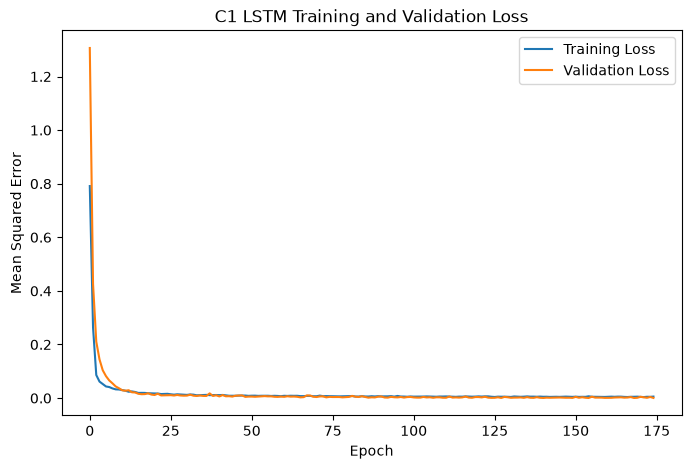

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(
    c1_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    c1_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("C1 LSTM Training and Validation Loss")
plt.legend()
plt.show()

In [69]:
c1_predictions_scaled = c1_model.predict(
    X_val_seq,
    verbose=0
)

c1_predictions = y_scaler.inverse_transform(
    c1_predictions_scaled
)

y_val_original = y_scaler.inverse_transform(
    y_val_seq
)

In [70]:
c1_fold1_results = []

for i, target in enumerate(targets):

    metrics = calculate_metrics(
        y_val_original[:, i],
        c1_predictions[:, i]
    )

    c1_fold1_results.append({
        "Target": target,
        **metrics
    })

c1_fold1_results = pd.DataFrame(
    c1_fold1_results
)

c1_fold1_results["Waste Stream"] = (
    c1_fold1_results["Target"]
    .map(target_names)
)

c1_fold1_results[
    ["Waste Stream", "RMSE", "MAE", "MAPE", "R2"]
].round(4)

,Waste Stream,RMSE,MAE,MAPE,R2
0,EFB,0.1014,0.0735,0.5043,0.9998
1,PKS,0.0272,0.0167,0.4968,0.9998
2,POME,0.2985,0.2407,0.5401,0.9998
3,Mesocarp Fibre,0.0625,0.0427,0.5158,0.9998


### 6.7 Rolling-Origin LSTM Configuration Evaluation

Each candidate LSTM architecture is evaluated across the 10 rolling-origin validation folds. Feature and target scalers are fitted independently within each training fold to prevent information leakage.

Early stopping monitors validation loss with a patience of 20 epochs and restores the weights associated with the lowest validation loss. Performance is calculated after predictions are transformed back to their original units.

In [71]:
lstm_validation_results = []

for config in lstm_configurations:

    print(f"Evaluating {config['name']}...")

    for fold_number, (train_idx, val_idx) in enumerate(
        rolling_splits,
        start=1
    ):

        # Prepare fold
        (
            X_train_seq,
            y_train_seq,
            X_val_seq,
            y_val_seq,
            X_scaler,
            y_scaler
        ) = prepare_lstm_fold(
            X,
            y,
            train_idx,
            val_idx,
            SEQUENCE_LENGTH
        )

        # Clear previous model
        keras.backend.clear_session()

        # Reset seed
        tf.keras.utils.set_random_seed(
            RANDOM_SEED
        )

        # Build model
        model = build_lstm_model(
            config,
            n_features=X_train_seq.shape[2],
            n_targets=y_train_seq.shape[1]
        )

        # Early stopping
        early_stopping = keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )

        # Train
        history = model.fit(
            X_train_seq,
            y_train_seq,
            validation_data=(
                X_val_seq,
                y_val_seq
            ),
            epochs=300,
            batch_size=config["batch_size"],
            callbacks=[early_stopping],
            verbose=0
        )

        # Predict validation year
        predictions_scaled = model.predict(
            X_val_seq,
            verbose=0
        )

        # Return predictions to original units
        predictions = y_scaler.inverse_transform(
            predictions_scaled
        )

        actual = y_scaler.inverse_transform(
            y_val_seq
        )

        # Evaluate each waste stream
        for target_index, target in enumerate(targets):

            metrics = calculate_metrics(
                actual[:, target_index],
                predictions[:, target_index]
            )

            lstm_validation_results.append({
                "Configuration": config["name"],
                "Fold": fold_number,
                "Validation_Year":
                    int(df.loc[val_idx, "Year"].iloc[0]),
                "Target": target,
                "Epochs":
                    len(history.history["loss"]),
                **metrics
            })

        print(
            f"  Fold {fold_number}: "
            f"{len(history.history['loss'])} epochs"
        )

Evaluating C1...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 1: 175 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 2: 159 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 3: 160 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 4: 142 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 5: 55 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 6: 155 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 7: 167 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 8: 90 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 9: 176 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 10: 155 epochs
Evaluating C2...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 1: 120 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 2: 112 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 3: 102 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 4: 99 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 5: 105 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 6: 95 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 7: 118 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 8: 161 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 9: 94 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 10: 151 epochs
Evaluating C3...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 1: 41 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 2: 127 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 3: 142 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 4: 77 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 5: 52 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 6: 64 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 7: 58 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 8: 71 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 9: 50 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 10: 100 epochs
Evaluating C4...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 1: 159 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 2: 40 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 3: 72 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 4: 84 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 5: 67 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 6: 89 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 7: 85 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 8: 67 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 9: 133 epochs


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 10: 152 epochs


In [72]:
lstm_validation_results = pd.DataFrame(
    lstm_validation_results
)

print(
    "Number of result rows:",
    len(lstm_validation_results)
)

lstm_validation_results.head()

Number of result rows: 160


,Configuration,Fold,Validation_Year,Target,Epochs,RMSE,MAE,MAPE,R2
0,C1,1,2012,EFB_1000MT,175,0.101360,0.073483,0.504337,0.999786
1,C1,1,2012,PKS_1000MT,175,0.027234,0.016653,0.496775,0.999792
2,C1,1,2012,POME_1000MT,175,0.298483,0.240652,0.540094,0.999787
3,C1,1,2012,Mesocarp_Fibre_1000MT,175,0.062496,0.042697,0.515830,0.999767
4,C1,2,2013,EFB_1000MT,159,0.119972,0.092154,0.652722,0.999658


In [73]:
lstm_summary = (
    lstm_validation_results
    .groupby(
        ["Configuration", "Target"]
    )
    .agg(
        Mean_RMSE=("RMSE", "mean"),
        SD_RMSE=("RMSE", "std"),
        Mean_MAE=("MAE", "mean"),
        Mean_MAPE=("MAPE", "mean"),
        Mean_R2=("R2", "mean"),
        Mean_Epochs=("Epochs", "mean")
    )
    .reset_index()
)

lstm_summary.round(4)

,Configuration,Target,Mean_RMSE,SD_RMSE,Mean_MAE,Mean_MAPE,Mean_R2,Mean_Epochs
0,C1,EFB_1000MT,0.3704,0.3643,0.2935,1.8615,0.9956,143.4
1,C1,Mesocarp_Fibre_1000MT,0.2127,0.1714,0.1765,1.8728,0.9967,143.4
2,C1,PKS_1000MT,0.0936,0.0728,0.0756,1.7603,0.9971,143.4
3,C1,POME_1000MT,0.9158,0.6569,0.7494,1.5786,0.9978,143.4
4,C2,EFB_1000MT,0.2166,0.1196,0.1785,1.1058,0.9991,115.7
5,C2,Mesocarp_Fibre_1000MT,0.1348,0.0634,0.1102,1.1590,0.9991,115.7
6,C2,PKS_1000MT,0.0668,0.0339,0.0530,1.2230,0.9989,115.7
7,C2,POME_1000MT,0.6819,0.4039,0.5611,1.1579,0.9990,115.7
8,C3,EFB_1000MT,0.6658,0.3169,0.5284,3.3182,0.9923,78.2
9,C3,Mesocarp_Fibre_1000MT,0.3672,0.1655,0.2927,3.1730,0.9934,78.2


In [74]:
best_lstm = (
    lstm_summary
    .loc[
        lstm_summary
        .groupby("Target")["Mean_RMSE"]
        .idxmin()
    ]
    .sort_values("Target")
    .reset_index(drop=True)
)

best_lstm[
    [
        "Target",
        "Configuration",
        "Mean_RMSE",
        "SD_RMSE",
        "Mean_MAPE",
        "Mean_R2",
        "Mean_Epochs"
    ]
].round(4)

,Target,Configuration,Mean_RMSE,SD_RMSE,Mean_MAPE,Mean_R2,Mean_Epochs
0,EFB_1000MT,C2,0.2166,0.1196,1.1058,0.9991,115.7
1,Mesocarp_Fibre_1000MT,C2,0.1348,0.0634,1.1590,0.9991,115.7
2,PKS_1000MT,C2,0.0668,0.0339,1.2230,0.9989,115.7
3,POME_1000MT,C2,0.6819,0.4039,1.1579,0.9990,115.7


### 6.8 LSTM Model Selection

Configuration C2 achieved the lowest mean rolling-origin validation RMSE for all four waste streams. C2 consists of a single LSTM layer with 64 units, 20% dropout, an Adam learning rate of 0.001 and a batch size of 16.

Across the 10 rolling-origin folds, C2 achieved mean RMSE values of 0.2166 for EFB, 0.0668 for PKS, 0.6819 for POME and 0.1348 for Mesocarp Fibre. Mean R² was approximately 0.999 across the four targets.

Because the same configuration performed best for every target, C2 was selected as the final multi-output LSTM architecture. As with the tree-based models, these results should be interpreted in the context of the deterministic relationship between FFB and the waste targets.

In [75]:
# Fit predictor scaler on development data only
final_X_scaler = StandardScaler()

X_train_scaled = final_X_scaler.fit_transform(
    X_train
)

X_test_scaled = final_X_scaler.transform(
    X_test
)

# Fit target scaler on development targets only
final_y_scaler = StandardScaler()

y_train_scaled = final_y_scaler.fit_transform(
    y_train
)

y_test_scaled = final_y_scaler.transform(
    y_test
)

In [76]:
X_final_train_seq, y_final_train_seq, _ = (
    create_lstm_sequences(
        X_train_scaled,
        y_train_scaled,
        SEQUENCE_LENGTH
    )
)

print("Final training X:",
      X_final_train_seq.shape)

print("Final training y:",
      y_final_train_seq.shape)

Final training X: (685, 12, 9)
Final training y: (685, 4)


In [77]:
test_historical_context = X_train_scaled[
    -(SEQUENCE_LENGTH - 1):
]

X_test_with_context = np.vstack([
    test_historical_context,
    X_test_scaled
])

X_final_test_seq = []

for i in range(
    SEQUENCE_LENGTH - 1,
    len(X_test_with_context)
):
    start = i - SEQUENCE_LENGTH + 1
    end = i + 1

    X_final_test_seq.append(
        X_test_with_context[start:end]
    )

X_final_test_seq = np.array(
    X_final_test_seq
)

y_final_test_seq = y_test_scaled

print("Final test X:",
      X_final_test_seq.shape)

print("Final test y:",
      y_final_test_seq.shape)

Final test X: (36, 12, 9)
Final test y: (36, 4)


In [78]:
c2_fold10 = lstm_validation_results[
    (lstm_validation_results["Configuration"] == "C2")
    & (lstm_validation_results["Fold"] == 10)
]

c2_fold10[
    [
        "Validation_Year",
        "Target",
        "Epochs",
        "RMSE",
        "MAPE",
        "R2"
    ]
].round(4)

,Validation_Year,Target,Epochs,RMSE,MAPE,R2
76,2021,EFB_1000MT,151,0.2553,0.9984,0.9994
77,2021,PKS_1000MT,151,0.0739,1.0047,0.9993
78,2021,POME_1000MT,151,0.7949,1.0023,0.9993
79,2021,Mesocarp_Fibre_1000MT,151,0.1582,0.9886,0.9993


In [79]:
final_lstm_epochs = int(
    c2_fold10["Epochs"].iloc[0]
)

print(
    "Selected final training epochs:",
    final_lstm_epochs
)

Selected final training epochs: 151


### 6.9 Final LSTM Training Strategy

The independent 2022–2024 test period is not used for early stopping or model selection.

The number of epochs for the final C2 model is determined from the final rolling-origin development fold, where the model is trained through 2020 and validated on 2021. Once this training duration is established, C2 is retrained using the complete 1964–2021 development dataset for the fixed number of epochs.

This preserves the independence of the 2022–2024 test period.

In [80]:
keras.backend.clear_session()

tf.keras.utils.set_random_seed(
    RANDOM_SEED
)

c2_config = next(
    config
    for config in lstm_configurations
    if config["name"] == "C2"
)

final_lstm_model = build_lstm_model(
    c2_config,
    n_features=X_final_train_seq.shape[2],
    n_targets=y_final_train_seq.shape[1]
)

final_lstm_history = final_lstm_model.fit(
    X_final_train_seq,
    y_final_train_seq,
    epochs=final_lstm_epochs,
    batch_size=c2_config["batch_size"],
    verbose=0
)

print(
    "Final LSTM training epochs:",
    len(final_lstm_history.history["loss"])
)

C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Final LSTM training epochs: 151


In [81]:
lstm_test_predictions_scaled = (
    final_lstm_model.predict(
        X_final_test_seq,
        verbose=0
    )
)

lstm_test_predictions = (
    final_y_scaler.inverse_transform(
        lstm_test_predictions_scaled
    )
)

lstm_test_actual = (
    final_y_scaler.inverse_transform(
        y_final_test_seq
    )
)

print(
    "Predictions:",
    lstm_test_predictions.shape
)

print(
    "Actual:",
    lstm_test_actual.shape
)

Predictions: (36, 4)
Actual: (36, 4)


In [82]:
lstm_test_results = []

for target_index, target in enumerate(targets):

    metrics = calculate_metrics(
        lstm_test_actual[:, target_index],
        lstm_test_predictions[:, target_index]
    )

    lstm_test_results.append({
        "Target": target,
        **metrics
    })

lstm_test_results = pd.DataFrame(
    lstm_test_results
)

lstm_test_results["Waste Stream"] = (
    lstm_test_results["Target"]
    .map(target_names)
)

lstm_test_results[
    [
        "Waste Stream",
        "RMSE",
        "MAE",
        "MAPE",
        "R2"
    ]
].round(4)

,Waste Stream,RMSE,MAE,MAPE,R2
0,EFB,0.6399,0.4196,1.2980,0.9965
1,PKS,0.1809,0.1177,1.3084,0.9963
2,POME,1.8736,1.2132,1.2492,0.9966
3,Mesocarp Fibre,0.3866,0.2634,1.4200,0.9964


### 6.10 LSTM Independent-Test Findings

The final C2 LSTM was trained for 151 epochs using the complete 1964–2021 development period. The training duration was determined using development-period rolling-origin validation, without using the independent test period for early stopping or model selection.

On the 2022–2024 independent test period, the LSTM achieved RMSE values of 0.6399 for EFB, 0.1809 for PKS, 1.8736 for POME and 0.3866 for Mesocarp Fibre. R² exceeded 0.996 across all four waste streams, while MAPE ranged from approximately 1.25% to 1.42%.

The LSTM produced lower RMSE than both Random Forest and XGBoost across all four waste streams, indicating stronger predictive performance among the machine-learning models evaluated. However, the conversion-factor baseline continued to provide exact predictions because the waste targets were deterministically derived from FFB. The LSTM results should therefore be interpreted within this data-generation context.

In [83]:
model_comparison = (
    rf_test_results[
        ["Target", "RMSE", "MAE", "MAPE", "R2"]
    ]
    .merge(
        xgb_test_results[
            ["Target", "RMSE", "MAE", "MAPE", "R2"]
        ],
        on="Target",
        suffixes=("_RF", "_XGB")
    )
    .merge(
        lstm_test_results[
            ["Target", "RMSE", "MAE", "MAPE", "R2"]
        ],
        on="Target"
    )
)

model_comparison = model_comparison.rename(
    columns={
        "RMSE": "RMSE_LSTM",
        "MAE": "MAE_LSTM",
        "MAPE": "MAPE_LSTM",
        "R2": "R2_LSTM"
    }
)

model_comparison["Waste Stream"] = (
    model_comparison["Target"]
    .map(target_names)
)

model_comparison[
    [
        "Waste Stream",
        "RMSE_RF",
        "RMSE_XGB",
        "RMSE_LSTM",
        "MAPE_RF",
        "MAPE_XGB",
        "MAPE_LSTM",
        "R2_RF",
        "R2_XGB",
        "R2_LSTM"
    ]
].round(4)

,Waste Stream,RMSE_RF,RMSE_XGB,RMSE_LSTM,MAPE_RF,MAPE_XGB,MAPE_LSTM,R2_RF,R2_XGB,R2_LSTM
0,EFB,1.4167,1.2578,0.6399,1.5771,1.5831,1.2980,0.9829,0.9866,0.9965
1,Mesocarp Fibre,0.8592,0.7181,0.3866,1.6077,1.4323,1.4200,0.9820,0.9875,0.9964
2,PKS,0.4069,0.3332,0.1809,1.6141,1.5414,1.3084,0.9811,0.9873,0.9963
3,POME,4.4452,3.6904,1.8736,1.6124,1.4924,1.2492,0.9808,0.9867,0.9966


## 7. Stacking Ensemble with Elastic Net

A stacking ensemble combines the predictions of Random Forest, XGBoost and LSTM using Elastic Net as a meta-learner.

To prevent leakage, the Elastic Net model is trained using out-of-fold predictions generated through the 10-fold rolling-origin validation procedure. Each base-model prediction used for meta-learning is therefore produced for a period that was not included in that base model's training data.

For each waste stream, the Elastic Net meta-learner receives three inputs: the Random Forest prediction, XGBoost prediction and LSTM prediction.

In [84]:
stacking_oof_records = []

print(
    "Expected OOF months:",
    len(rolling_splits) * 12
)

Expected OOF months: 120


In [85]:
print("rf_tuning_results columns:")
print(rf_tuning_results.columns.tolist())

print("\nShape:")
print(rf_tuning_results.shape)

print("\nFirst rows:")
display(rf_tuning_results.head())

rf_tuning_results columns:
['Configuration', 'n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'Mean_RMSE', 'SD_RMSE']

Shape:
(6, 7)

First rows:


,Configuration,n_estimators,max_depth,min_samples_leaf,max_features,Mean_RMSE,SD_RMSE
0,1,100,NaN,1,1.0,0.792735,0.819157
1,2,200,NaN,1,1.0,0.790982,0.837232
2,3,300,NaN,1,1.0,0.781695,0.820434
3,4,200,10.0,1,1.0,0.776958,0.809815
4,5,200,NaN,2,1.0,0.808792,0.843806


In [86]:
print(rf_tuning_results.columns.tolist())

['Configuration', 'n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'Mean_RMSE', 'SD_RMSE']


In [87]:
%whos DataFrame

Variable                        Type         Data/Info
------------------------------------------------------
X                               DataFrame    Shape: (732, 9)
X_fold_train                    DataFrame    Shape: (576, 9)
X_fold_val                      DataFrame    Shape: (12, 9)
X_no_ffb                        DataFrame    Shape: (732, 8)
X_rf_train                      DataFrame    Shape: (576, 9)
X_rf_val                        DataFrame    Shape: (12, 9)
X_test                          DataFrame    Shape: (36, 9)
X_test_no_ffb                   DataFrame    Shape: (36, 8)
X_train                         DataFrame    Shape: (696, 9)
X_train_no_ffb                  DataFrame    Shape: (696, 8)
baseline_results                DataFrame    Shape: (4, 6)
baseline_summary                DataFrame    Shape: (4, 5)
best_lstm                       DataFrame    Shape: (4, 8)
best_rf_by_target               DataFrame    Shape: (4, 8)
best_rf_no_ffb                  DataFrame    Sha

In [88]:
print("Shape:", best_rf_by_target.shape)
print("Columns:", best_rf_by_target.columns.tolist())
display(best_rf_by_target)

Shape: (4, 8)
Columns: ['Target', 'Configuration', 'n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'Mean_RMSE', 'SD_RMSE']


,Target,Configuration,n_estimators,max_depth,min_samples_leaf,max_features,Mean_RMSE,SD_RMSE
0,EFB_1000MT,4,200,10.0,1,1.0,0.776958,0.809815
1,Mesocarp_Fibre_1000MT,4,200,10.0,1,1.0,0.457711,0.472978
2,PKS_1000MT,3,300,NaN,1,1.0,0.209764,0.212188
3,POME_1000MT,3,300,NaN,1,1.0,2.251148,2.303975


In [89]:
print("Shape:", best_rf_by_target.shape)
print("Columns:", best_rf_by_target.columns.tolist())
display(best_rf_by_target)

Shape: (4, 8)
Columns: ['Target', 'Configuration', 'n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'Mean_RMSE', 'SD_RMSE']


,Target,Configuration,n_estimators,max_depth,min_samples_leaf,max_features,Mean_RMSE,SD_RMSE
0,EFB_1000MT,4,200,10.0,1,1.0,0.776958,0.809815
1,Mesocarp_Fibre_1000MT,4,200,10.0,1,1.0,0.457711,0.472978
2,PKS_1000MT,3,300,NaN,1,1.0,0.209764,0.212188
3,POME_1000MT,3,300,NaN,1,1.0,2.251148,2.303975


In [90]:
rf_oof_records = []

for fold_number, (train_idx, val_idx) in enumerate(
    rolling_splits,
    start=1
):

    validation_year = int(
        df.loc[val_idx, "Year"].iloc[0]
    )

    for _, row in best_rf_by_target.iterrows():

        target = row["Target"]

        max_depth = (
            None
            if pd.isna(row["max_depth"])
            else int(row["max_depth"])
        )

        model = RandomForestRegressor(
            n_estimators=int(row["n_estimators"]),
            max_depth=max_depth,
            min_samples_leaf=int(row["min_samples_leaf"]),
            max_features=row["max_features"],
            random_state=RANDOM_SEED,
            n_jobs=-1
        )

        model.fit(
            X.loc[train_idx],
            y.loc[train_idx, target]
        )

        predictions = model.predict(
            X.loc[val_idx]
        )

        for position, idx in enumerate(val_idx):

            rf_oof_records.append({
                "Index": idx,
                "Fold": fold_number,
                "Validation_Year": validation_year,
                "Target": target,
                "RF_Prediction": predictions[position],
                "Actual": y.loc[idx, target]
            })

rf_oof = pd.DataFrame(rf_oof_records)

print("RF OOF rows:", len(rf_oof))
display(rf_oof.head())

RF OOF rows: 480


,Index,Fold,Validation_Year,Target,RF_Prediction,Actual
0,576,1,2012,EFB_1000MT,10.304085,10.340
1,577,1,2012,EFB_1000MT,12.383780,12.408
2,578,1,2012,EFB_1000MT,20.726420,20.680
3,579,1,2012,EFB_1000MT,26.747265,26.884
4,580,1,2012,EFB_1000MT,29.343370,28.952


In [91]:
print("Rows per target:")
print(rf_oof.groupby("Target").size())

print(
    "\nValidation years:",
    sorted(rf_oof["Validation_Year"].unique())
)

print(
    "\nDuplicate target-month combinations:",
    rf_oof.duplicated(
        subset=["Index", "Target"]
    ).sum()
)

Rows per target:
Target
EFB_1000MT               120
Mesocarp_Fibre_1000MT    120
PKS_1000MT               120
POME_1000MT              120
dtype: int64

Validation years: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Duplicate target-month combinations: 0


In [92]:
rf_oof_check = (
    rf_oof[
        rf_oof["Target"] == "EFB_1000MT"
    ]
    .sort_values("Index")
)

print(
    "First OOF observation:",
    df.loc[
        rf_oof_check["Index"].iloc[0],
        ["Year", "Month"]
    ].to_dict()
)

print(
    "Last OOF observation:",
    df.loc[
        rf_oof_check["Index"].iloc[-1],
        ["Year", "Month"]
    ].to_dict()
)

First OOF observation: {'Year': 2012, 'Month': 'Jan'}
Last OOF observation: {'Year': 2021, 'Month': 'Dec'}


In [93]:
print("Shape:", best_xgb.shape)
print("Columns:", best_xgb.columns.tolist())
display(best_xgb)

Shape: (4, 9)
Columns: ['Target', 'Configuration', 'n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'Mean_RMSE', 'SD_RMSE']


,Target,Configuration,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,Mean_RMSE,SD_RMSE
0,EFB_1000MT,3,300,3,0.05,1.0,1.0,0.572159,0.482127
1,Mesocarp_Fibre_1000MT,3,300,3,0.05,1.0,1.0,0.331947,0.287278
2,PKS_1000MT,5,200,3,0.10,1.0,1.0,0.154060,0.136734
3,POME_1000MT,3,300,3,0.05,1.0,1.0,1.678720,1.434004


In [94]:
xgb_oof_records = []

for fold_number, (train_idx, val_idx) in enumerate(
    rolling_splits,
    start=1
):

    validation_year = int(
        df.loc[val_idx, "Year"].iloc[0]
    )

    for _, row in best_xgb.iterrows():

        target = row["Target"]

        model = XGBRegressor(
            n_estimators=int(row["n_estimators"]),
            max_depth=int(row["max_depth"]),
            learning_rate=float(row["learning_rate"]),
            subsample=float(row["subsample"]),
            colsample_bytree=float(row["colsample_bytree"]),
            objective="reg:squarederror",
            tree_method="hist",
            random_state=RANDOM_SEED,
            n_jobs=-1
        )

        model.fit(
            X.loc[train_idx],
            y.loc[train_idx, target]
        )

        predictions = model.predict(
            X.loc[val_idx]
        )

        for position, idx in enumerate(val_idx):

            xgb_oof_records.append({
                "Index": idx,
                "Fold": fold_number,
                "Validation_Year": validation_year,
                "Target": target,
                "XGB_Prediction": predictions[position],
                "Actual": y.loc[idx, target]
            })

xgb_oof = pd.DataFrame(xgb_oof_records)

print("XGB OOF rows:", len(xgb_oof))
display(xgb_oof.head())

XGB OOF rows: 480


,Index,Fold,Validation_Year,Target,XGB_Prediction,Actual
0,576,1,2012,EFB_1000MT,10.314056,10.340
1,577,1,2012,EFB_1000MT,12.353354,12.408
2,578,1,2012,EFB_1000MT,20.472845,20.680
3,579,1,2012,EFB_1000MT,25.817970,26.884
4,580,1,2012,EFB_1000MT,29.867159,28.952


In [95]:
print("Rows per target:")
print(xgb_oof.groupby("Target").size())

print(
    "\nValidation years:",
    sorted(xgb_oof["Validation_Year"].unique())
)

print(
    "\nDuplicate target-month combinations:",
    xgb_oof.duplicated(
        subset=["Index", "Target"]
    ).sum()
)

Rows per target:
Target
EFB_1000MT               120
Mesocarp_Fibre_1000MT    120
PKS_1000MT               120
POME_1000MT              120
dtype: int64

Validation years: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Duplicate target-month combinations: 0


In [96]:
rf_keys = (
    rf_oof[["Index", "Fold", "Validation_Year", "Target"]]
    .sort_values(["Target", "Index"])
    .reset_index(drop=True)
)

xgb_keys = (
    xgb_oof[["Index", "Fold", "Validation_Year", "Target"]]
    .sort_values(["Target", "Index"])
    .reset_index(drop=True)
)

print(
    "RF and XGB OOF keys match:",
    rf_keys.equals(xgb_keys)
)

RF and XGB OOF keys match: True


In [97]:
lstm_oof_records = []

c2_config = next(
    config
    for config in lstm_configurations
    if config["name"] == "C2"
)

for fold_number, (train_idx, val_idx) in enumerate(
    rolling_splits,
    start=1
):

    validation_year = int(
        df.loc[val_idx, "Year"].iloc[0]
    )

    print(
        f"Processing Fold {fold_number} "
        f"(Validation {validation_year})..."
    )

    # Prepare this fold using training-only scalers
    (
        X_train_seq,
        y_train_seq,
        X_val_seq,
        y_val_seq,
        X_scaler,
        y_scaler
    ) = prepare_lstm_fold(
        X,
        y,
        train_idx,
        val_idx,
        sequence_length=SEQUENCE_LENGTH
    )

    # Recover the C2 epoch count selected for this fold
    fold_c2_results = lstm_validation_results[
        (lstm_validation_results["Configuration"] == "C2")
        & (lstm_validation_results["Fold"] == fold_number)
    ]

    fold_epochs = int(
        fold_c2_results["Epochs"].iloc[0]
    )

    # Fresh model for this fold
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_SEED)

    model = build_lstm_model(
        c2_config,
        n_features=X_train_seq.shape[2],
        n_targets=y_train_seq.shape[1]
    )

    # Retrain using the development-only epoch count
    model.fit(
        X_train_seq,
        y_train_seq,
        epochs=fold_epochs,
        batch_size=c2_config["batch_size"],
        verbose=0
    )

    # Predict the validation year
    predictions_scaled = model.predict(
        X_val_seq,
        verbose=0
    )

    predictions = y_scaler.inverse_transform(
        predictions_scaled
    )

    actual = y_scaler.inverse_transform(
        y_val_seq
    )

    # Store one record per month and target
    for month_position, idx in enumerate(val_idx):

        for target_index, target in enumerate(targets):

            lstm_oof_records.append({
                "Index": idx,
                "Fold": fold_number,
                "Validation_Year": validation_year,
                "Target": target,
                "LSTM_Prediction":
                    predictions[
                        month_position,
                        target_index
                    ],
                "Actual":
                    actual[
                        month_position,
                        target_index
                    ]
            })

lstm_oof = pd.DataFrame(lstm_oof_records)

print("\nLSTM OOF rows:", len(lstm_oof))
display(lstm_oof.head())

Processing Fold 1 (Validation 2012)...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing Fold 2 (Validation 2013)...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing Fold 3 (Validation 2014)...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing Fold 4 (Validation 2015)...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing Fold 5 (Validation 2016)...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing Fold 6 (Validation 2017)...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing Fold 7 (Validation 2018)...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing Fold 8 (Validation 2019)...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing Fold 9 (Validation 2020)...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing Fold 10 (Validation 2021)...


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



LSTM OOF rows: 480


,Index,Fold,Validation_Year,Target,LSTM_Prediction,Actual
0,576,1,2012,EFB_1000MT,10.600761,10.340
1,576,1,2012,PKS_1000MT,2.861635,2.820
2,576,1,2012,POME_1000MT,31.165903,30.550
3,576,1,2012,Mesocarp_Fibre_1000MT,6.237824,6.110
4,577,1,2012,EFB_1000MT,12.803680,12.408


In [98]:
print("Rows per target:")
print(lstm_oof.groupby("Target").size())

print(
    "\nValidation years:",
    sorted(lstm_oof["Validation_Year"].unique())
)

print(
    "\nDuplicate target-month combinations:",
    lstm_oof.duplicated(
        subset=["Index", "Target"]
    ).sum()
)

Rows per target:
Target
EFB_1000MT               120
Mesocarp_Fibre_1000MT    120
PKS_1000MT               120
POME_1000MT              120
dtype: int64

Validation years: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Duplicate target-month combinations: 0


In [99]:
lstm_keys = (
    lstm_oof[
        ["Index", "Fold", "Validation_Year", "Target"]
    ]
    .sort_values(["Target", "Index"])
    .reset_index(drop=True)
)

print(
    "RF and LSTM OOF keys match:",
    rf_keys.equals(lstm_keys)
)

print(
    "XGB and LSTM OOF keys match:",
    xgb_keys.equals(lstm_keys)
)

RF and LSTM OOF keys match: True
XGB and LSTM OOF keys match: True


In [100]:
stacking_oof = (
    rf_oof[
        [
            "Index",
            "Fold",
            "Validation_Year",
            "Target",
            "RF_Prediction",
            "Actual"
        ]
    ]
    .merge(
        xgb_oof[
            [
                "Index",
                "Fold",
                "Validation_Year",
                "Target",
                "XGB_Prediction"
            ]
        ],
        on=[
            "Index",
            "Fold",
            "Validation_Year",
            "Target"
        ],
        how="inner"
    )
    .merge(
        lstm_oof[
            [
                "Index",
                "Fold",
                "Validation_Year",
                "Target",
                "LSTM_Prediction"
            ]
        ],
        on=[
            "Index",
            "Fold",
            "Validation_Year",
            "Target"
        ],
        how="inner"
    )
    .sort_values(["Target", "Index"])
    .reset_index(drop=True)
)

print("Stacking OOF shape:", stacking_oof.shape)

display(stacking_oof.head())

Stacking OOF shape: (480, 8)


,Index,Fold,Validation_Year,Target,RF_Prediction,Actual,XGB_Prediction,LSTM_Prediction
0,576,1,2012,EFB_1000MT,10.304085,10.340,10.314056,10.600761
1,577,1,2012,EFB_1000MT,12.383780,12.408,12.353354,12.803680
2,578,1,2012,EFB_1000MT,20.726420,20.680,20.472845,21.021061
3,579,1,2012,EFB_1000MT,26.747265,26.884,25.817970,27.292212
4,580,1,2012,EFB_1000MT,29.343370,28.952,29.867159,29.256336


In [101]:
print("Rows per target:")
print(stacking_oof.groupby("Target").size())

print(
    "\nDuplicate target-month combinations:",
    stacking_oof.duplicated(
        subset=["Index", "Target"]
    ).sum()
)

print(
    "\nMissing values:"
)
print(
    stacking_oof[
        [
            "RF_Prediction",
            "XGB_Prediction",
            "LSTM_Prediction",
            "Actual"
        ]
    ].isna().sum()
)

Rows per target:
Target
EFB_1000MT               120
Mesocarp_Fibre_1000MT    120
PKS_1000MT               120
POME_1000MT              120
dtype: int64

Duplicate target-month combinations: 0

Missing values:
RF_Prediction      0
XGB_Prediction     0
LSTM_Prediction    0
Actual             0
dtype: int64


In [102]:
display(
    stacking_oof[
        stacking_oof["Target"] == "EFB_1000MT"
    ][
        [
            "Index",
            "Validation_Year",
            "RF_Prediction",
            "XGB_Prediction",
            "LSTM_Prediction",
            "Actual"
        ]
    ].head(12).round(4)
)

,Index,Validation_Year,RF_Prediction,XGB_Prediction,LSTM_Prediction,Actual
0,576,2012,10.3041,10.314100,10.600800,10.340
1,577,2012,12.3838,12.353400,12.803700,12.408
2,578,2012,20.7264,20.472799,21.021099,20.680
3,579,2012,26.7473,25.818001,27.292200,26.884
4,580,2012,29.3434,29.867201,29.256300,28.952
5,581,2012,25.2369,24.460300,25.062099,24.816
6,582,2012,20.7059,20.464899,20.669800,20.680
7,583,2012,18.6790,18.589600,18.515900,18.612
8,584,2012,14.5035,14.484700,14.474200,14.476
9,585,2012,12.3765,12.352300,12.321000,12.408


In [103]:
from sklearn.linear_model import ElasticNet

In [104]:
elastic_net_grid = [
    {"alpha": 0.0001, "l1_ratio": 0.1},
    {"alpha": 0.0001, "l1_ratio": 0.5},
    {"alpha": 0.0001, "l1_ratio": 0.9},
    {"alpha": 0.001,  "l1_ratio": 0.1},
    {"alpha": 0.001,  "l1_ratio": 0.5},
    {"alpha": 0.001,  "l1_ratio": 0.9},
    {"alpha": 0.01,   "l1_ratio": 0.1},
    {"alpha": 0.01,   "l1_ratio": 0.5},
    {"alpha": 0.01,   "l1_ratio": 0.9},
    {"alpha": 0.1,    "l1_ratio": 0.1},
    {"alpha": 0.1,    "l1_ratio": 0.5},
    {"alpha": 0.1,    "l1_ratio": 0.9}
]

print(
    "Number of Elastic Net configurations:",
    len(elastic_net_grid)
)

Number of Elastic Net configurations: 12


In [105]:
print("Stacking OOF shape:", stacking_oof.shape)

print("\nRows per target:")
print(stacking_oof.groupby("Target").size())

print(
    "\nDuplicates:",
    stacking_oof.duplicated(
        subset=["Index", "Target"]
    ).sum()
)

print("\nMissing values:")
print(
    stacking_oof[
        ["RF_Prediction", "XGB_Prediction",
         "LSTM_Prediction", "Actual"]
    ].isna().sum()
)

Stacking OOF shape: (480, 8)

Rows per target:
Target
EFB_1000MT               120
Mesocarp_Fibre_1000MT    120
PKS_1000MT               120
POME_1000MT              120
dtype: int64

Duplicates: 0

Missing values:
RF_Prediction      0
XGB_Prediction     0
LSTM_Prediction    0
Actual             0
dtype: int64


In [106]:
meta_validation_years = [
    2017, 2018, 2019, 2020, 2021
]

meta_splits = []

for val_year in meta_validation_years:

    meta_train_mask = (
        stacking_oof["Validation_Year"] < val_year
    )

    meta_val_mask = (
        stacking_oof["Validation_Year"] == val_year
    )

    meta_splits.append({
        "Validation_Year": val_year,
        "Train_Mask": meta_train_mask,
        "Val_Mask": meta_val_mask
    })

    print(
        f"Meta validation {val_year}: "
        f"train years "
        f"{stacking_oof.loc[meta_train_mask, 'Validation_Year'].min()}"
        f"–"
        f"{stacking_oof.loc[meta_train_mask, 'Validation_Year'].max()}, "
        f"validation year {val_year}"
    )

Meta validation 2017: train years 2012–2016, validation year 2017
Meta validation 2018: train years 2012–2017, validation year 2018
Meta validation 2019: train years 2012–2018, validation year 2019
Meta validation 2020: train years 2012–2019, validation year 2020
Meta validation 2021: train years 2012–2020, validation year 2021


In [107]:
elastic_net_tuning_records = []

meta_features = [
    "RF_Prediction",
    "XGB_Prediction",
    "LSTM_Prediction"
]

for target in targets:

    target_data = (
        stacking_oof[
            stacking_oof["Target"] == target
        ]
        .sort_values("Index")
        .copy()
    )

    for config_number, config in enumerate(
        elastic_net_grid,
        start=1
    ):

        fold_rmses = []

        for val_year in meta_validation_years:

            train_data = target_data[
                target_data["Validation_Year"] < val_year
            ]

            val_data = target_data[
                target_data["Validation_Year"] == val_year
            ]

            model = ElasticNet(
                alpha=config["alpha"],
                l1_ratio=config["l1_ratio"],
                max_iter=10000,
                random_state=RANDOM_SEED
            )

            model.fit(
                train_data[meta_features],
                train_data["Actual"]
            )

            predictions = model.predict(
                val_data[meta_features]
            )

            rmse = np.sqrt(
                mean_squared_error(
                    val_data["Actual"],
                    predictions
                )
            )

            fold_rmses.append(rmse)

        elastic_net_tuning_records.append({
            "Target": target,
            "Configuration": config_number,
            "alpha": config["alpha"],
            "l1_ratio": config["l1_ratio"],
            "Mean_RMSE": np.mean(fold_rmses),
            "SD_RMSE": np.std(fold_rmses)
        })

elastic_net_tuning = pd.DataFrame(
    elastic_net_tuning_records
)

print("Tuning rows:", len(elastic_net_tuning))
display(elastic_net_tuning.head())

C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.928947e+00, tolerance: 3.163e+00
  model = cd_fast.enet_coordinate_descent(


Tuning rows: 48


,Target,Configuration,alpha,l1_ratio,Mean_RMSE,SD_RMSE
0,EFB_1000MT,1,0.0001,0.1,0.585254,0.308392
1,EFB_1000MT,2,0.0001,0.5,0.585630,0.308634
2,EFB_1000MT,3,0.0001,0.9,0.586003,0.308876
3,EFB_1000MT,4,0.0010,0.1,0.585175,0.311247
4,EFB_1000MT,5,0.0010,0.5,0.588412,0.313693


In [108]:
best_elastic_net = (
    elastic_net_tuning
    .loc[
        elastic_net_tuning
        .groupby("Target")["Mean_RMSE"]
        .idxmin()
    ]
    .sort_values("Target")
    .reset_index(drop=True)
)

best_elastic_net["Waste Stream"] = (
    best_elastic_net["Target"]
    .map(target_names)
)

display(
    best_elastic_net[
        [
            "Waste Stream",
            "Configuration",
            "alpha",
            "l1_ratio",
            "Mean_RMSE",
            "SD_RMSE"
        ]
    ].round(4)
)

,Waste Stream,Configuration,alpha,l1_ratio,Mean_RMSE,SD_RMSE
0,EFB,4,0.0010,0.1,0.5852,0.3112
1,Mesocarp Fibre,1,0.0001,0.1,0.3475,0.1771
2,PKS,1,0.0001,0.1,0.1631,0.0829
3,POME,7,0.0100,0.1,1.7290,0.9076


In [109]:
%whos

Variable                         Type                     Data/Info
-------------------------------------------------------------------
ElasticNet                       ABCMeta                  <class 'sklearn.linear_mo<...>nate_descent.ElasticNet'>
RANDOM_SEED                      int                      42
RandomForestRegressor            ABCMeta                  <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
SEQUENCE_LENGTH                  int                      12
StandardScaler                   type                     <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                                DataFrame                Shape: (732, 9)
XGBRegressor                     type                     <class 'xgboost.sklearn.XGBRegressor'>
X_final_test_seq                 ndarray                  36x12x9: 3888 elems, type `float64`, 31104 bytes
X_final_train_seq                ndarray                  685x12x9: 73980 elems, type `float64`, 591840 bytes (577.96875 k

In [110]:
xgb_test_predictions = {}

for target in targets:
    xgb_test_predictions[target] = (
        final_xgb_models[target].predict(X_test)
    )

print("XGBoost prediction shapes:")

for target, pred in xgb_test_predictions.items():
    print(target, pred.shape)

XGBoost prediction shapes:
EFB_1000MT (36,)
PKS_1000MT (36,)
POME_1000MT (36,)
Mesocarp_Fibre_1000MT (36,)


In [111]:
xgb_recheck = []

for target in targets:

    metrics = calculate_metrics(
        y_test[target],
        xgb_test_predictions[target]
    )

    xgb_recheck.append({
        "Target": target,
        **metrics
    })

xgb_recheck = pd.DataFrame(xgb_recheck)

xgb_recheck["Waste Stream"] = (
    xgb_recheck["Target"].map(target_names)
)

display(
    xgb_recheck[
        ["Waste Stream", "RMSE", "MAE", "MAPE", "R2"]
    ].round(4)
)

,Waste Stream,RMSE,MAE,MAPE,R2
0,EFB,1.2578,0.6080,1.5831,0.9866
1,PKS,0.3332,0.1605,1.5414,0.9873
2,POME,3.6904,1.7103,1.4924,0.9867
3,Mesocarp Fibre,0.7181,0.3321,1.4323,0.9875


In [112]:
stacking_test_records = []

for target_index, target in enumerate(targets):

    rf_pred = rf_test_predictions[target]
    xgb_pred = xgb_test_predictions[target]

    lstm_pred = lstm_test_predictions[
        :, target_index
    ]

    actual = y_test[target].values

    for i in range(len(y_test)):

        stacking_test_records.append({
            "Index": y_test.index[i],
            "Target": target,
            "RF_Prediction": rf_pred[i],
            "XGB_Prediction": xgb_pred[i],
            "LSTM_Prediction": lstm_pred[i],
            "Actual": actual[i]
        })

stacking_test = pd.DataFrame(
    stacking_test_records
)

print("Stacking test shape:", stacking_test.shape)

Stacking test shape: (144, 6)


In [113]:
print("Rows per target:")
print(stacking_test.groupby("Target").size())

print(
    "\nDuplicates:",
    stacking_test.duplicated(
        subset=["Index", "Target"]
    ).sum()
)

print("\nMissing values:")
print(
    stacking_test[
        [
            "RF_Prediction",
            "XGB_Prediction",
            "LSTM_Prediction",
            "Actual"
        ]
    ].isna().sum()
)

Rows per target:
Target
EFB_1000MT               36
Mesocarp_Fibre_1000MT    36
PKS_1000MT               36
POME_1000MT              36
dtype: int64

Duplicates: 0

Missing values:
RF_Prediction      0
XGB_Prediction     0
LSTM_Prediction    0
Actual             0
dtype: int64


In [114]:
final_elastic_net_models = {}
stacking_test_results = []
stacking_test_predictions = {}

for _, row in best_elastic_net.iterrows():

    target = row["Target"]

    train_data = (
        stacking_oof[
            stacking_oof["Target"] == target
        ]
        .sort_values("Index")
    )

    test_data = (
        stacking_test[
            stacking_test["Target"] == target
        ]
        .sort_values("Index")
    )

    model = ElasticNet(
        alpha=float(row["alpha"]),
        l1_ratio=float(row["l1_ratio"]),
        max_iter=10000,
        random_state=RANDOM_SEED
    )

    model.fit(
        train_data[meta_features],
        train_data["Actual"]
    )

    predictions = model.predict(
        test_data[meta_features]
    )

    final_elastic_net_models[target] = model
    stacking_test_predictions[target] = predictions

    metrics = calculate_metrics(
        test_data["Actual"],
        predictions
    )

    stacking_test_results.append({
        "Target": target,
        **metrics
    })

stacking_test_results = pd.DataFrame(
    stacking_test_results
)

stacking_test_results["Waste Stream"] = (
    stacking_test_results["Target"]
    .map(target_names)
)

display(
    stacking_test_results[
        ["Waste Stream", "RMSE", "MAE", "MAPE", "R2"]
    ].round(4)
)

,Waste Stream,RMSE,MAE,MAPE,R2
0,EFB,0.6669,0.4310,1.3324,0.9962
1,Mesocarp Fibre,0.3888,0.2380,1.2541,0.9963
2,PKS,0.1698,0.1140,1.3338,0.9967
3,POME,1.9221,1.2517,1.3168,0.9964


In [115]:
elastic_net_coefficients = []

for target, model in final_elastic_net_models.items():

    elastic_net_coefficients.append({
        "Waste Stream": target_names[target],
        "RF_Coefficient": model.coef_[0],
        "XGB_Coefficient": model.coef_[1],
        "LSTM_Coefficient": model.coef_[2],
        "Intercept": model.intercept_
    })

elastic_net_coefficients = pd.DataFrame(
    elastic_net_coefficients
)

display(
    elastic_net_coefficients.round(4)
)

,Waste Stream,RF_Coefficient,XGB_Coefficient,LSTM_Coefficient,Intercept
0,EFB,-0.3964,0.8135,0.6083,-0.3344
1,Mesocarp Fibre,-0.4165,0.8551,0.5862,-0.1944
2,PKS,-0.4045,0.7969,0.6333,-0.0904
3,POME,-0.4525,0.8815,0.5968,-1.0025


In [116]:
final_model_comparison = (
    model_comparison
    .merge(
        stacking_test_results[
            ["Target", "RMSE", "MAE", "MAPE", "R2"]
        ],
        on="Target",
        how="left"
    )
    .rename(
        columns={
            "RMSE": "RMSE_Stacking",
            "MAE": "MAE_Stacking",
            "MAPE": "MAPE_Stacking",
            "R2": "R2_Stacking"
        }
    )
)

display(
    final_model_comparison[
        [
            "Waste Stream",
            "RMSE_RF",
            "RMSE_XGB",
            "RMSE_LSTM",
            "RMSE_Stacking",
            "R2_RF",
            "R2_XGB",
            "R2_LSTM",
            "R2_Stacking"
        ]
    ].round(4)
)

,Waste Stream,RMSE_RF,RMSE_XGB,RMSE_LSTM,RMSE_Stacking,R2_RF,R2_XGB,R2_LSTM,R2_Stacking
0,EFB,1.4167,1.2578,0.6399,0.6669,0.9829,0.9866,0.9965,0.9962
1,Mesocarp Fibre,0.8592,0.7181,0.3866,0.3888,0.9820,0.9875,0.9964,0.9963
2,PKS,0.4069,0.3332,0.1809,0.1698,0.9811,0.9873,0.9963,0.9967
3,POME,4.4452,3.6904,1.8736,1.9221,0.9808,0.9867,0.9966,0.9964


### 7.1 Stacking Ensemble Results

The Elastic Net stacking ensemble combined out-of-fold predictions from Random Forest, XGBoost and LSTM. Meta-learner hyperparameters were selected using expanding-window temporal validation over the 2012–2021 out-of-fold development period, while the 2022–2024 independent test period remained excluded from model selection.

On the independent test period, the stacking ensemble achieved RMSE values of 0.6669 for EFB, 0.1698 for PKS, 1.9221 for POME and 0.3888 for Mesocarp Fibre, with R² values above 0.996 across all four targets.

The ensemble substantially outperformed Random Forest and XGBoost across all four waste streams. However, stacking did not consistently outperform the LSTM. The ensemble achieved a lower RMSE for PKS, while the LSTM achieved slightly lower RMSE for EFB, POME and Mesocarp Fibre. This demonstrates that combining multiple learners did not automatically guarantee superior predictive performance relative to the strongest individual base learner.

The Elastic Net coefficients were positive for XGBoost and LSTM and negative for Random Forest across all four targets. These coefficients should not be interpreted as simple percentage contributions because the base-model predictions are strongly correlated and Elastic Net applies regularisation.

Importantly, the conversion-factor baseline continued to reproduce the independent-test targets exactly at the stored dataset precision. The machine-learning results must therefore be interpreted in the context of the deterministic relationship between FFB and the derived waste quantities.

### 7.2 Selected Elastic Net Hyperparameters

| Waste Stream | Alpha | L1 Ratio |
|---|---:|---:|
| EFB | 0.0010 | 0.1 |
| PKS | 0.0001 | 0.1 |
| POME | 0.0100 | 0.1 |
| Mesocarp Fibre | 0.0001 | 0.1 |

All four target-specific meta-learners selected an L1 ratio of 0.1, indicating that the selected Elastic Net configurations placed greater emphasis on L2-style regularisation while retaining an L1 component.

In [117]:
stacking_improvement = final_model_comparison[
    [
        "Target",
        "Waste Stream",
        "RMSE_RF",
        "RMSE_XGB",
        "RMSE_LSTM",
        "RMSE_Stacking"
    ]
].copy()

stacking_improvement[
    "Improvement_vs_RF_pct"
] = (
    (
        stacking_improvement["RMSE_RF"]
        - stacking_improvement["RMSE_Stacking"]
    )
    / stacking_improvement["RMSE_RF"]
    * 100
)

stacking_improvement[
    "Improvement_vs_XGB_pct"
] = (
    (
        stacking_improvement["RMSE_XGB"]
        - stacking_improvement["RMSE_Stacking"]
    )
    / stacking_improvement["RMSE_XGB"]
    * 100
)

stacking_improvement[
    "Improvement_vs_LSTM_pct"
] = (
    (
        stacking_improvement["RMSE_LSTM"]
        - stacking_improvement["RMSE_Stacking"]
    )
    / stacking_improvement["RMSE_LSTM"]
    * 100
)

display(
    stacking_improvement[
        [
            "Waste Stream",
            "Improvement_vs_RF_pct",
            "Improvement_vs_XGB_pct",
            "Improvement_vs_LSTM_pct"
        ]
    ].round(2)
)

,Waste Stream,Improvement_vs_RF_pct,Improvement_vs_XGB_pct,Improvement_vs_LSTM_pct
0,EFB,52.93,46.98,-4.21
1,Mesocarp Fibre,54.75,45.86,-0.56
2,PKS,58.26,49.03,6.14
3,POME,56.76,47.92,-2.59


## 8. Uncertainty Quantification with Conformal Prediction

Point predictions provide estimates of palm oil waste quantities but do not indicate the uncertainty surrounding those estimates. To quantify predictive uncertainty, additive conformal prediction is applied to the stacking ensemble.

The conformal procedure uses residuals from the development period to estimate an uncertainty margin around each prediction. The independent 2022–2024 test targets are not used to construct or calibrate the prediction intervals.

For a nominal 95% prediction interval, the lower and upper bounds are defined as:

Lower Bound = Prediction − q

Upper Bound = Prediction + q

where q is a conformal residual quantile estimated from development-period prediction errors.

In [118]:
conformal_calibration_records = []

for target in targets:

    target_data = (
        stacking_oof[
            stacking_oof["Target"] == target
        ]
        .sort_values("Index")
        .copy()
    )

    best_row = best_elastic_net[
        best_elastic_net["Target"] == target
    ].iloc[0]

    for val_year in meta_validation_years:

        calibration_train = target_data[
            target_data["Validation_Year"] < val_year
        ]

        calibration_val = target_data[
            target_data["Validation_Year"] == val_year
        ]

        model = ElasticNet(
            alpha=float(best_row["alpha"]),
            l1_ratio=float(best_row["l1_ratio"]),
            max_iter=10000,
            random_state=RANDOM_SEED
        )

        model.fit(
            calibration_train[meta_features],
            calibration_train["Actual"]
        )

        predictions = model.predict(
            calibration_val[meta_features]
        )

        for position, (_, obs) in enumerate(
            calibration_val.iterrows()
        ):

            conformal_calibration_records.append({
                "Index": obs["Index"],
                "Validation_Year": val_year,
                "Target": target,
                "Prediction": predictions[position],
                "Actual": obs["Actual"],
                "Absolute_Error": abs(
                    obs["Actual"]
                    - predictions[position]
                )
            })

conformal_calibration = pd.DataFrame(
    conformal_calibration_records
)

print(
    "Conformal calibration shape:",
    conformal_calibration.shape
)

print("\nRows per target:")
print(
    conformal_calibration
    .groupby("Target")
    .size()
)

Conformal calibration shape: (240, 6)

Rows per target:
Target
EFB_1000MT               60
Mesocarp_Fibre_1000MT    60
PKS_1000MT               60
POME_1000MT              60
dtype: int64


In [119]:
print(
    "Calibration years:",
    sorted(
        conformal_calibration[
            "Validation_Year"
        ].unique()
    )
)

print(
    "\nDuplicate target-months:",
    conformal_calibration.duplicated(
        subset=["Index", "Target"]
    ).sum()
)

print(
    "\nMissing values:",
    conformal_calibration[
        [
            "Prediction",
            "Actual",
            "Absolute_Error"
        ]
    ].isna().sum()
)

Calibration years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Duplicate target-months: 0

Missing values: Prediction        0
Actual            0
Absolute_Error    0
dtype: int64


In [120]:
alpha = 0.05

conformal_quantiles = {}

for target in targets:

    target_errors = (
        conformal_calibration.loc[
            conformal_calibration["Target"] == target,
            "Absolute_Error"
        ]
        .sort_values()
        .to_numpy()
    )

    n = len(target_errors)

    rank = int(
        np.ceil((n + 1) * (1 - alpha))
    )

    rank = min(rank, n)

    q = target_errors[rank - 1]

    conformal_quantiles[target] = q

    print(
        f"{target_names[target]}: "
        f"n={n}, rank={rank}, q={q:.4f}"
    )

EFB: n=60, rank=58, q=1.9652
PKS: n=60, rank=58, q=0.5626
POME: n=60, rank=58, q=5.7259
Mesocarp Fibre: n=60, rank=58, q=1.1844


In [121]:
conformal_quantile_table = pd.DataFrame([
    {
        "Target": target,
        "Waste Stream": target_names[target],
        "Calibration_n": 60,
        "Confidence_Level": "95%",
        "Conformal_q": q
    }
    for target, q in conformal_quantiles.items()
])

display(
    conformal_quantile_table.round(4)
)

,Target,Waste Stream,Calibration_n,Confidence_Level,Conformal_q
0,EFB_1000MT,EFB,60,95%,1.9652
1,PKS_1000MT,PKS,60,95%,0.5626
2,POME_1000MT,POME,60,95%,5.7259
3,Mesocarp_Fibre_1000MT,Mesocarp Fibre,60,95%,1.1844


In [122]:
conformal_test_records = []

for target in targets:

    test_data = (
        stacking_test[
            stacking_test["Target"] == target
        ]
        .sort_values("Index")
        .copy()
    )

    predictions = stacking_test_predictions[target]
    q = conformal_quantiles[target]

    for position, (_, obs) in enumerate(
        test_data.iterrows()
    ):

        prediction = predictions[position]

        lower = prediction - q
        upper = prediction + q
        actual = obs["Actual"]

        conformal_test_records.append({
            "Index": obs["Index"],
            "Target": target,
            "Actual": actual,
            "Prediction": prediction,
            "Lower_95": lower,
            "Upper_95": upper,
            "Covered": (
                lower <= actual <= upper
            ),
            "Interval_Width": upper - lower
        })

conformal_test = pd.DataFrame(
    conformal_test_records
)

print("Conformal test shape:", conformal_test.shape)

display(
    conformal_test.head()
)

Conformal test shape: (144, 8)


,Index,Target,Actual,Prediction,Lower_95,Upper_95,Covered,Interval_Width
0,696,EFB_1000MT,15.40,15.610606,13.645427,17.575785,True,3.930358
1,697,EFB_1000MT,18.48,18.667503,16.702324,20.632682,True,3.930358
2,698,EFB_1000MT,30.80,31.272397,29.307218,33.237576,True,3.930358
3,699,EFB_1000MT,40.04,40.263808,38.298629,42.228986,True,3.930358
4,700,EFB_1000MT,43.12,44.083561,42.118382,46.048740,True,3.930358


In [123]:
conformal_coverage = (
    conformal_test
    .groupby("Target")
    .agg(
        Coverage=("Covered", "mean"),
        Mean_Interval_Width=(
            "Interval_Width", "mean"
        ),
        Test_Observations=("Covered", "size")
    )
    .reset_index()
)

conformal_coverage["Coverage_pct"] = (
    conformal_coverage["Coverage"] * 100
)

conformal_coverage["Waste Stream"] = (
    conformal_coverage["Target"]
    .map(target_names)
)

display(
    conformal_coverage[
        [
            "Waste Stream",
            "Test_Observations",
            "Coverage_pct",
            "Mean_Interval_Width"
        ]
    ].round(2)
)

,Waste Stream,Test_Observations,Coverage_pct,Mean_Interval_Width
0,EFB,36,97.22,3.93
1,Mesocarp Fibre,36,97.22,2.37
2,PKS,36,100.00,1.13
3,POME,36,97.22,11.45


### 8.1 Conformal Prediction Results

Additive conformal prediction was used to quantify uncertainty around the stacking ensemble predictions. The conformal calibration residuals were generated from temporal development-period predictions for 2017–2021, while the independent 2022–2024 test targets were excluded from interval calibration.

For the nominal 95% prediction intervals, the finite-sample conformal quantiles were 1.9652 kt for EFB, 0.5626 kt for PKS, 5.7259 kt for POME and 1.1844 kt for Mesocarp Fibre. These values represent the target-specific uncertainty margins added to and subtracted from the stacking point predictions.

On the independent 2022–2024 test period, empirical coverage was 97.22% for EFB, 97.22% for Mesocarp Fibre, 100.00% for PKS and 97.22% for POME. Therefore, the observed coverage met or exceeded the nominal 95% level for all four waste streams. The corresponding mean interval widths were 3.93 kt, 2.37 kt, 1.13 kt and 11.45 kt, respectively.

The results indicate that the conformal intervals provided high empirical coverage on the independent test period. However, the observed coverage should not be interpreted as a guarantee of future 95% coverage, particularly given the relatively small 36-month test period and the temporal and deterministic characteristics of the dataset.

In [124]:
coverage_counts = (
    conformal_test
    .groupby("Target")["Covered"]
    .agg(["sum", "count"])
    .reset_index()
)

coverage_counts["Not_Covered"] = (
    coverage_counts["count"]
    - coverage_counts["sum"]
)

coverage_counts["Waste Stream"] = (
    coverage_counts["Target"].map(target_names)
)

display(
    coverage_counts[
        [
            "Waste Stream",
            "sum",
            "Not_Covered",
            "count"
        ]
    ].rename(
        columns={
            "sum": "Covered",
            "count": "Total"
        }
    )
)

,Waste Stream,Covered,Not_Covered,Total
0,EFB,35,1,36
1,Mesocarp Fibre,35,1,36
2,PKS,36,0,36
3,POME,35,1,36


In [125]:
date_lookup = pd.Series(
    pd.to_datetime(
        {
            "year": df.loc[y_test.index, "Year"].astype(int),
            "month": df.loc[y_test.index, "Month_Number"].astype(int),
            "day": 1
        }
    ).values,
    index=y_test.index
)

conformal_test["Date"] = (
    conformal_test["Index"].map(date_lookup)
)

print(
    conformal_test[
        ["Index", "Date", "Target"]
    ].head()
)

print(
    "\nDate range:",
    conformal_test["Date"].min(),
    "to",
    conformal_test["Date"].max()
)

   Index       Date      Target
0    696 2022-01-01  EFB_1000MT
1    697 2022-02-01  EFB_1000MT
2    698 2022-03-01  EFB_1000MT
3    699 2022-04-01  EFB_1000MT
4    700 2022-05-01  EFB_1000MT

Date range: 2022-01-01 00:00:00 to 2024-12-01 00:00:00


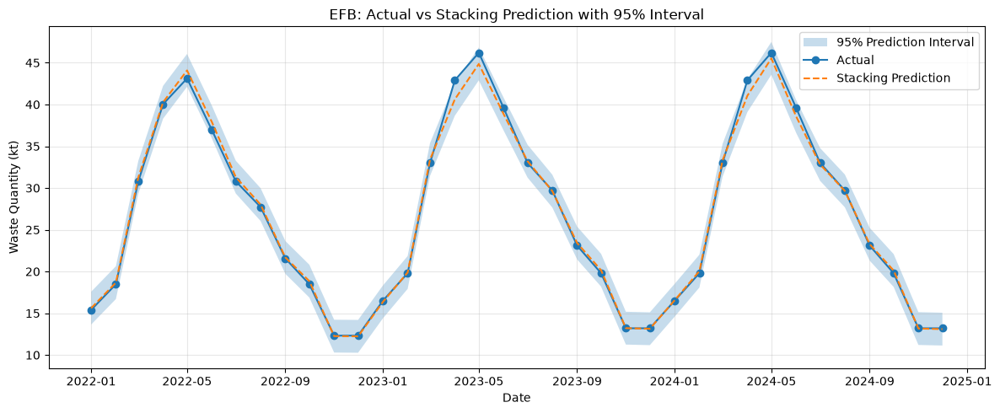

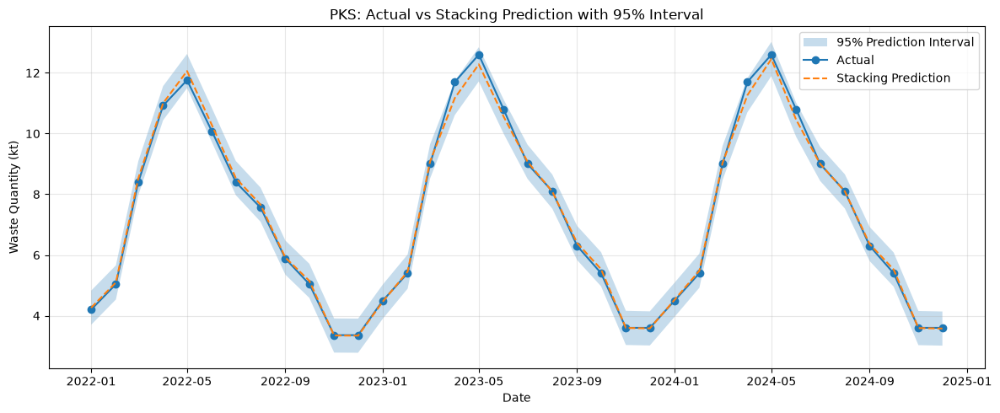

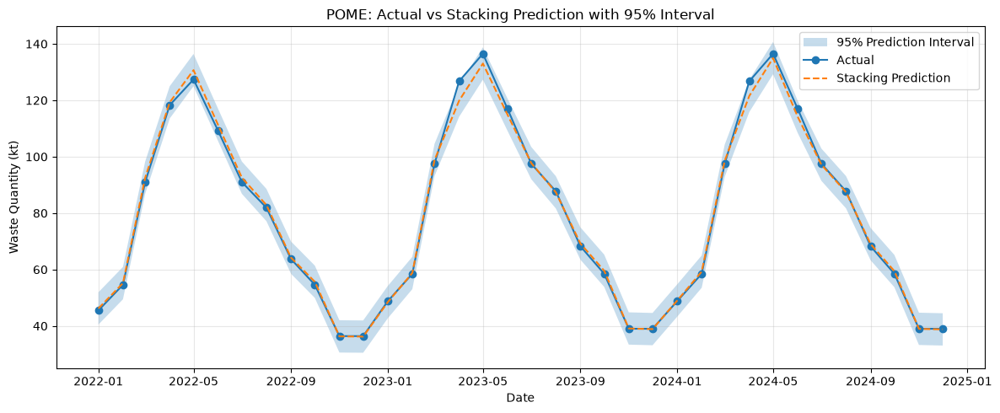

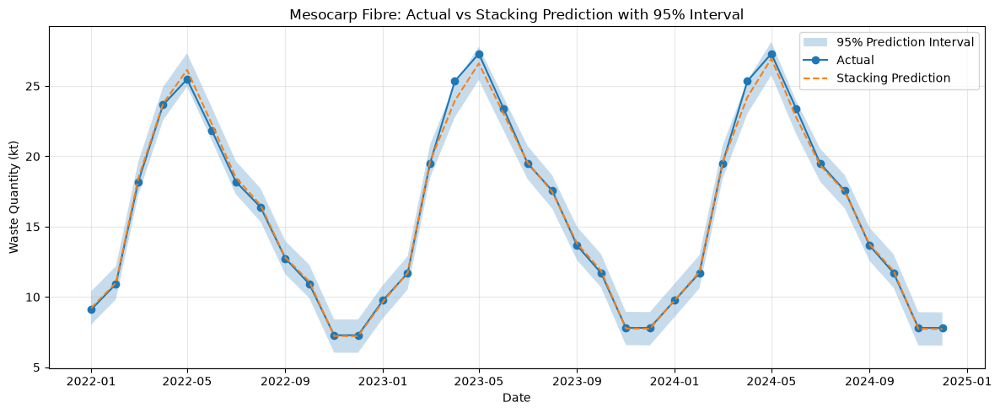

In [126]:
for target in targets:

    plot_data = (
        conformal_test[
            conformal_test["Target"] == target
        ]
        .sort_values("Date")
    )

    plt.figure(figsize=(12, 5))

    plt.fill_between(
        plot_data["Date"],
        plot_data["Lower_95"],
        plot_data["Upper_95"],
        alpha=0.25,
        label="95% Prediction Interval"
    )

    plt.plot(
        plot_data["Date"],
        plot_data["Actual"],
        marker="o",
        label="Actual"
    )

    plt.plot(
        plot_data["Date"],
        plot_data["Prediction"],
        linestyle="--",
        label="Stacking Prediction"
    )

    plt.title(
        f"{target_names[target]}: "
        "Actual vs Stacking Prediction with 95% Interval"
    )

    plt.xlabel("Date")
    plt.ylabel("Waste Quantity (kt)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()

## 9. Model Explainability

Model explainability was used to investigate which predictors contributed most strongly to the machine-learning predictions.

Particular attention was given to FFB because exploratory analysis identified an extremely strong relationship between FFB and the four derived waste quantities. Random Forest feature importance and SHAP analysis are used to examine the contribution of FFB relative to the temporal and environmental predictors.

The explainability results are interpreted alongside the conversion-factor baseline and the no-FFB sensitivity analysis to avoid attributing predictive importance to causal relationships.

In [127]:
rf_feature_importance_records = []

for target in targets:

    model = rf_final_models[target]

    for feature, importance in zip(
        features,
        model.feature_importances_
    ):

        rf_feature_importance_records.append({
            "Target": target,
            "Waste Stream": target_names[target],
            "Feature": feature,
            "Importance": importance
        })

rf_feature_importance = pd.DataFrame(
    rf_feature_importance_records
)

display(
    rf_feature_importance
    .sort_values(
        ["Target", "Importance"],
        ascending=[True, False]
    )
    .round(6)
)

,Target,Waste Stream,Feature,Importance
3,EFB_1000MT,EFB,FFB_1000MT,0.999300
0,EFB_1000MT,EFB,Year,0.000185
5,EFB_1000MT,EFB,Rainfall_mm,0.000150
6,EFB_1000MT,EFB,Humidity_pct,0.000095
7,EFB_1000MT,EFB,Wind_Speed_ms,0.000093
4,EFB_1000MT,EFB,Avg_Temperature_C,0.000083
8,EFB_1000MT,EFB,Solar_Radiation_Wm2,0.000060
1,EFB_1000MT,EFB,Month_Number,0.000033
2,EFB_1000MT,EFB,Quarter,0.000002
30,Mesocarp_Fibre_1000MT,Mesocarp Fibre,FFB_1000MT,0.999236


In [128]:
rf_average_importance = (
    rf_feature_importance
    .groupby("Feature")["Importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

display(
    rf_average_importance.round(6)
)

,Feature,Importance
0,FFB_1000MT,0.999225
1,Year,0.000220
2,Rainfall_mm,0.000137
3,Wind_Speed_ms,0.000103
4,Avg_Temperature_C,0.000101
5,Humidity_pct,0.000096
6,Solar_Radiation_Wm2,0.000088
7,Month_Number,0.000028
8,Quarter,0.000002


In [129]:
ffb_importance = (
    rf_feature_importance[
        rf_feature_importance["Feature"]
        == "FFB_1000MT"
    ][
        ["Waste Stream", "Importance"]
    ]
    .copy()
)

ffb_importance["Importance_pct"] = (
    ffb_importance["Importance"] * 100
)

display(
    ffb_importance[
        ["Waste Stream", "Importance_pct"]
    ].round(4)
)

,Waste Stream,Importance_pct
3,EFB,99.9300
12,PKS,99.9155
21,POME,99.9207
30,Mesocarp Fibre,99.9236


### 9.1 Random Forest Feature Importance

Random Forest feature importance showed overwhelming predictive dominance by FFB. Averaged across the four waste streams, FFB accounted for approximately 99.92% of total feature importance, while each of the remaining temporal and environmental predictors contributed less than 0.03% individually.

At the target level, the importance attributed to FFB was 99.93% for EFB, 99.92% for PKS, 99.92% for POME and 99.92% for Mesocarp Fibre. This indicates that the Random Forest models relied almost entirely on FFB when generating waste-quantity predictions.

This result is consistent with the exploratory correlation analysis, the exact performance of the conversion-factor baseline on the independent test period, and the substantial deterioration in model performance when FFB was removed. However, feature importance represents predictive contribution rather than causal influence. In this dataset, the dominance of FFB is expected because the waste targets were derived using FFB-based conversion relationships.

In [130]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=5>
  res = process_handler(cmd, _system_body)
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=7>
  res = process_handler(cmd, _system_body)


In [131]:
import shap

print("SHAP version:", shap.__version__)

C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\shap\plots\colors\_colors.py:47: PendingDeprecationWarning: The set_bad function will be deprecated in a future version. Use cmap.with_extremes(bad=...) or Colormap(bad=...) instead.
  red_blue.set_bad(gray_rgb.tolist(), 1.0)
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\shap\plots\colors\_colors.py:48: PendingDeprecationWarning: The set_over function will be deprecated in a future version. Use cmap.with_extremes(over=...) or Colormap(over=...) instead.
  red_blue.set_over(gray_rgb.tolist(), 1.0)
C:\Users\hp\anaconda3\envs\palmoil\Lib\site-packages\shap\plots\colors\_colors.py:49: PendingDeprecationWarning: The set_under function will be deprecated in a future version. Use 

SHAP version: 0.51.0


In [132]:
target = "EFB_1000MT"

xgb_model = final_xgb_models[target]

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("Test data shape:", X_test.shape)

SHAP values shape: (36, 9)
Test data shape: (36, 9)


In [133]:
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [134]:
mean_abs_shap = np.abs(
    shap_values
).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": features,
    "Mean_Absolute_SHAP": mean_abs_shap
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

display(
    shap_importance.round(6)
)

,Feature,Mean_Absolute_SHAP
3,FFB_1000MT,13.709652
4,Avg_Temperature_C,0.098219
0,Year,0.079208
5,Rainfall_mm,0.053885
1,Month_Number,0.024893
7,Wind_Speed_ms,0.008220
8,Solar_Radiation_Wm2,0.006833
6,Humidity_pct,0.004500
2,Quarter,0.000000


In [135]:
shap_importance["SHAP_pct"] = (
    shap_importance["Mean_Absolute_SHAP"]
    / shap_importance["Mean_Absolute_SHAP"].sum()
    * 100
)

display(
    shap_importance[
        [
            "Feature",
            "Mean_Absolute_SHAP",
            "SHAP_pct"
        ]
    ].round(4)
)

,Feature,Mean_Absolute_SHAP,SHAP_pct
3,FFB_1000MT,13.7097,98.028198
4,Avg_Temperature_C,0.0982,0.702300
0,Year,0.0792,0.566400
5,Rainfall_mm,0.0539,0.385300
1,Month_Number,0.0249,0.178000
7,Wind_Speed_ms,0.0082,0.058800
8,Solar_Radiation_Wm2,0.0068,0.048900
6,Humidity_pct,0.0045,0.032200
2,Quarter,0.0000,0.000000


C:\Users\hp\AppData\Local\Temp\ipykernel_46852\1301988101.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


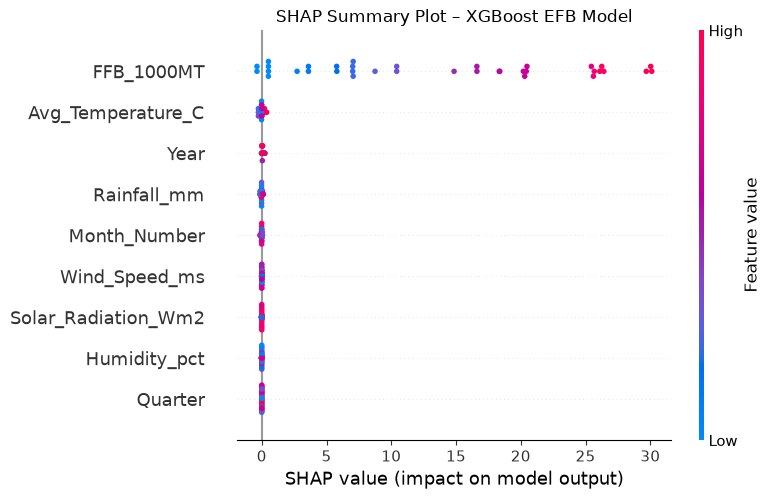

In [136]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features,
    show=False
)

plt.title(
    "SHAP Summary Plot – XGBoost EFB Model"
)

plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_46852\2259989336.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


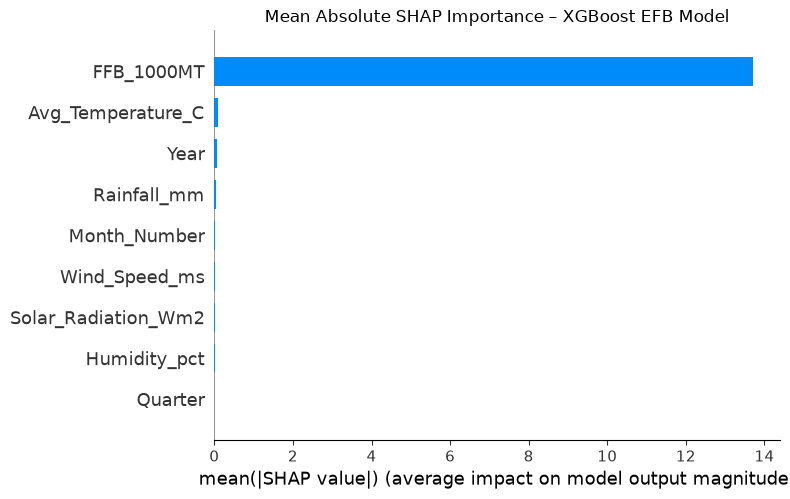

In [137]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features,
    plot_type="bar",
    show=False
)

plt.title(
    "Mean Absolute SHAP Importance – XGBoost EFB Model"
)

plt.tight_layout()
plt.show()

### 9.2 SHAP Analysis

SHAP analysis was applied to the final XGBoost EFB model to examine the contribution of individual predictors to the independent-test predictions. Mean absolute SHAP values showed that FFB overwhelmingly dominated the model's predictions, accounting for approximately 98.03% of total SHAP importance.

The remaining predictors made comparatively small contributions. Average temperature accounted for approximately 0.70%, Year for 0.57%, Rainfall for 0.39%, Month Number for 0.18%, and each remaining predictor contributed less than 0.1%.

The SHAP findings are consistent with the Random Forest feature-importance analysis, where FFB accounted for approximately 99.92% of average feature importance across the four waste streams. Together, the two explainability approaches demonstrate that the high predictive performance of the machine-learning models is driven predominantly by FFB rather than by the environmental or temporal variables.

This finding should be interpreted in the context of the dataset construction. The waste quantities were derived using FFB-based conversion relationships; therefore, the dominance of FFB represents predictive importance within this dataset and should not be interpreted as evidence of causal influence.

In [138]:
all_shap_importance = []

for target in targets:

    model = final_xgb_models[target]

    explainer = shap.TreeExplainer(model)

    target_shap_values = explainer.shap_values(
        X_test
    )

    mean_abs_values = np.abs(
        target_shap_values
    ).mean(axis=0)

    percentages = (
        mean_abs_values
        / mean_abs_values.sum()
        * 100
    )

    for feature, mean_shap, percentage in zip(
        features,
        mean_abs_values,
        percentages
    ):

        all_shap_importance.append({
            "Target": target,
            "Waste Stream": target_names[target],
            "Feature": feature,
            "Mean_Absolute_SHAP": mean_shap,
            "SHAP_pct": percentage
        })

all_shap_importance = pd.DataFrame(
    all_shap_importance
)

display(
    all_shap_importance[
        all_shap_importance["Feature"]
        == "FFB_1000MT"
    ][
        [
            "Waste Stream",
            "Mean_Absolute_SHAP",
            "SHAP_pct"
        ]
    ].round(4)
)

,Waste Stream,Mean_Absolute_SHAP,SHAP_pct
3,EFB,13.709700,98.028198
12,PKS,3.733800,97.774597
21,POME,40.576599,98.141998
30,Mesocarp Fibre,8.106300,98.165604


In [139]:
average_shap_importance = (
    all_shap_importance
    .groupby("Feature")["SHAP_pct"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

display(
    average_shap_importance.round(4)
)

,Feature,SHAP_pct
0,FFB_1000MT,98.027603
1,Avg_Temperature_C,0.614900
2,Year,0.585800
3,Rainfall_mm,0.378500
4,Month_Number,0.227700
5,Wind_Speed_ms,0.076400
6,Humidity_pct,0.047500
7,Solar_Radiation_Wm2,0.041700
8,Quarter,0.000000


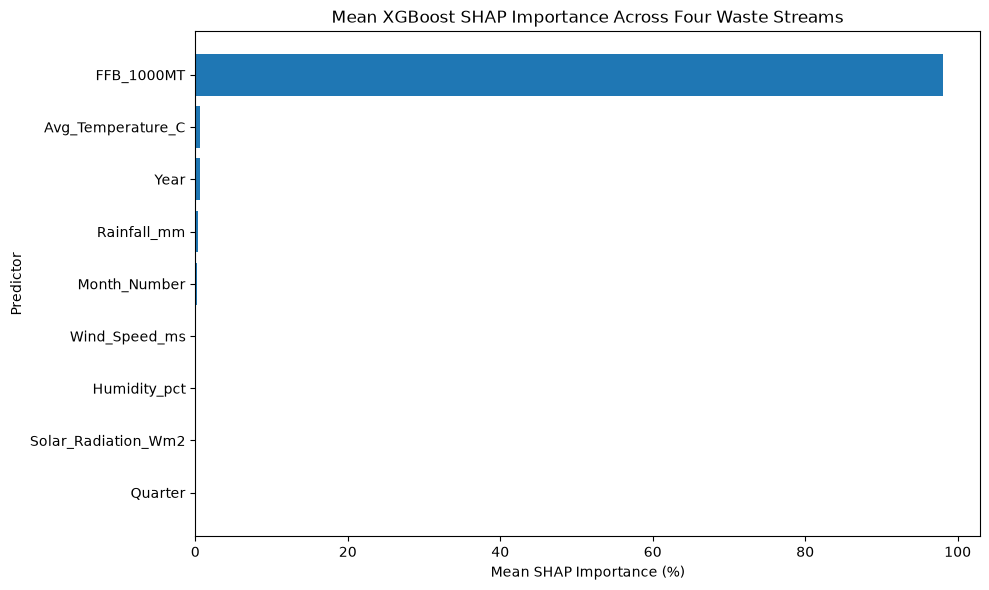

In [140]:
plot_data = (
    average_shap_importance
    .sort_values("SHAP_pct")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["SHAP_pct"]
)

plt.xlabel("Mean SHAP Importance (%)")
plt.ylabel("Predictor")
plt.title(
    "Mean XGBoost SHAP Importance "
    "Across Four Waste Streams"
)

plt.tight_layout()
plt.show()

### 9.3 Cross-Target SHAP Findings

The dominance of FFB was consistent across all four XGBoost target models. FFB accounted for 98.03% of total mean absolute SHAP importance for EFB, 97.77% for PKS, 98.14% for POME and 98.17% for Mesocarp Fibre.

This consistency indicates that the XGBoost models relied predominantly on FFB regardless of the waste stream being predicted. The finding also agrees with the Random Forest feature-importance analysis, which attributed approximately 99.92% of average importance to FFB.

The explainability results reinforce the methodological importance of the conversion-factor baseline and the no-FFB sensitivity analysis. Because the waste targets were derived from FFB-based conversion relationships, very high predictive performance when FFB is included should not be interpreted as evidence that the machine-learning models discovered complex relationships between environmental conditions and waste generation. Instead, much of their predictive accuracy reflects the strong structural relationship already embedded in the dataset.

Nevertheless, the no-FFB experiments showed that the remaining temporal and environmental predictors retained some predictive information, particularly for XGBoost, although performance deteriorated substantially compared with models containing FFB.

In [141]:
final_summary = final_model_comparison[
    [
        "Waste Stream",
        "RMSE_RF",
        "RMSE_XGB",
        "RMSE_LSTM",
        "RMSE_Stacking"
    ]
].copy()

# Add conversion-factor baseline
final_summary["RMSE_Conversion_Baseline"] = 0.0

# Add conformal coverage
coverage_lookup = (
    conformal_coverage
    .set_index("Waste Stream")["Coverage_pct"]
)

final_summary["Conformal_Coverage_pct"] = (
    final_summary["Waste Stream"]
    .map(coverage_lookup)
)

display(
    final_summary.round(4)
)

,Waste Stream,RMSE_RF,RMSE_XGB,RMSE_LSTM,RMSE_Stacking,RMSE_Conversion_Baseline,Conformal_Coverage_pct
0,EFB,1.4167,1.2578,0.6399,0.6669,0.0,97.2222
1,Mesocarp Fibre,0.8592,0.7181,0.3866,0.3888,0.0,97.2222
2,PKS,0.4069,0.3332,0.1809,0.1698,0.0,100.0000
3,POME,4.4452,3.6904,1.8736,1.9221,0.0,97.2222


## 10. Overall Results Summary

The independent-test results demonstrate that all four machine-learning approaches achieved high predictive accuracy for palm oil waste quantities during 2022–2024. XGBoost consistently outperformed Random Forest, while the LSTM achieved lower RMSE than both tree-based models across all four waste streams.

The stacking ensemble substantially improved upon Random Forest and XGBoost. Relative to Random Forest, stacking reduced RMSE by approximately 52.93%–58.26%, while improvements relative to XGBoost ranged from approximately 45.86% to 49.03%. However, stacking did not consistently outperform the strongest individual learner. The LSTM achieved slightly lower RMSE for EFB, POME and Mesocarp Fibre, while stacking improved upon the LSTM for PKS by approximately 6.14%. Therefore, ensemble learning provided competitive performance but did not universally improve upon the strongest base learner.

The conformal uncertainty analysis produced empirical independent-test coverage of 97.22% for EFB, Mesocarp Fibre and POME and 100% for PKS against a nominal 95% level. These results indicate high empirical coverage on the 36-month test period, although they should not be interpreted as a guarantee of equivalent future coverage.

Most importantly, the conversion-factor baseline reproduced all four independent-test targets exactly at the stored dataset precision. Random Forest feature importance attributed approximately 99.92% of average importance to FFB, while XGBoost SHAP analysis attributed approximately 97.77%–98.17% of total importance to FFB across the four targets. Removing FFB substantially degraded predictive performance. Together, these findings demonstrate that the very high machine-learning accuracy is largely explained by the structural relationship between FFB and the derived waste quantities. Consequently, the machine-learning results should be interpreted as predictive performance within the constructed dataset rather than evidence of complex causal relationships between environmental conditions and waste generation.

### Methodological Note on Uncertainty Quantification

The conformal procedure used temporally ordered development-period residuals rather than independent-test residuals, thereby preserving the separation of the 2022–2024 test period. However, the data are temporally structured and the model-selection and calibration stages share information from the broader development framework. Therefore, the reported conformal intervals should primarily be interpreted through their observed empirical test coverage rather than as strict finite-sample coverage guarantees under an independent and identically distributed assumption.

## 11. Conclusion

This notebook developed and evaluated Random Forest, XGBoost, LSTM and Elastic Net stacking models for predicting four palm oil waste streams using temporally ordered development and independent test data. On the 2022–2024 test period, all machine-learning models achieved strong predictive performance. The LSTM produced the lowest RMSE for EFB, POME and Mesocarp Fibre, while the stacking ensemble produced the lowest machine-learning RMSE for PKS and substantially outperformed Random Forest and XGBoost across all four targets.

Conformal prediction provided uncertainty estimates around the stacking predictions, with empirical test coverage ranging from 97.22% to 100% against a nominal 95% level. However, the conversion-factor baseline reproduced all test targets exactly at the stored dataset precision. Feature importance and SHAP analysis further showed that FFB overwhelmingly dominated model predictions, while removing FFB substantially reduced predictive performance.

Overall, the results demonstrate the importance of evaluating complex machine-learning models against simple domain-informed baselines. Although the machine-learning models achieved high predictive accuracy, their performance must be interpreted in the context of the strong structural relationship between FFB and the derived waste quantities. Future work should therefore evaluate the framework using independently measured waste quantities and richer production and environmental data.